In [1]:
!pip install kaggle mne numpy scipy pandas pytorch_lightning pytorch_metric_learning braindecode -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.8/127.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 448.8/448.8 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.4/178.4 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 107.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have

In [2]:
# Running on Kaggle - dataset is already available in /kaggle/input/
# Dataset structure: /kaggle/input/ALS_EEG4/dataset/
print("Running on Kaggle Notebook")
print("Dataset location: /kaggle/input/EEG_ALS/dataset/")

Running on Kaggle Notebook
Dataset location: /kaggle/input/EEG_ALS/dataset/


In [3]:
# Set Kaggle dataset path
# On Kaggle, datasets are mounted at /kaggle/input/<dataset-name>/
DATASET_PATH = "/kaggle/input/eeg-als/dataset"

print(f"Dataset path: {DATASET_PATH}")

Dataset path: /kaggle/input/eeg-als/dataset


In [4]:
# List contents of dataset folder
import os

print("Contents of dataset folder:")
for item in sorted(os.listdir(DATASET_PATH))[:20]:
    print(f"  {item}")

Contents of dataset folder:
  ALS01
  ALS02
  ALS03
  ALS04
  ALS05
  ALS06
  id1
  id10
  id100
  id101
  id102
  id103
  id104
  id105
  id106
  id107
  id108
  id109
  id11
  id110


In [5]:
# Count subjects in Kaggle dataset
import os

all_items = os.listdir(DATASET_PATH)
healthy_count = len([d for d in all_items if d.startswith('id')])
als_count = len([d for d in all_items if d.startswith('ALS')])

print(f"Healthy subjects (id*): {healthy_count}")
print(f"ALS subjects (ALS*): {als_count}")
print(f"Total subjects: {healthy_count + als_count}")

Healthy subjects (id*): 170
ALS subjects (ALS*): 6
Total subjects: 176


In [6]:
# Verify dataset is accessible
import os

if os.path.exists(DATASET_PATH):
    print(f"✓ Dataset found at: {DATASET_PATH}")
else:
    print(f"✗ Dataset NOT found at: {DATASET_PATH}")
    print("Please check the dataset name and path")

✓ Dataset found at: /kaggle/input/eeg-als/dataset


In [7]:
# Show sample subject structure
import os
import glob

sample_subject = os.path.join(DATASET_PATH, "ALS01")
if os.path.exists(sample_subject):
    print(f"Sample structure for ALS01:")
    for item in sorted(os.listdir(sample_subject)):
        print(f"  {item}")

Sample structure for ALS01:
  recording_time.json
  time1
  time10
  time2
  time3
  time4
  time5
  time6
  time7
  time8
  time9


In [8]:
# Verify full dataset structure
import os
import glob

print("Checking Kaggle dataset structure...")

healthy_subjects = sorted([os.path.basename(p) for p in glob.glob(os.path.join(DATASET_PATH, "id*"))])
als_subjects = sorted([os.path.basename(p) for p in glob.glob(os.path.join(DATASET_PATH, "ALS*"))])

print(f"\nHealthy subjects: {len(healthy_subjects)}")
print(f"ALS subjects: {len(als_subjects)}")

# Check sample subject structure
sample = als_subjects[0] if als_subjects else healthy_subjects[0]
subject_path = os.path.join(DATASET_PATH, sample)
time_folders = sorted(glob.glob(os.path.join(subject_path, "time*")))
print(f"\nSample subject '{sample}' has {len(time_folders)} time recordings")

if time_folders:
    scenario_folders = sorted(glob.glob(os.path.join(time_folders[0], "scenario*")))
    print(f"  First time folder has {len(scenario_folders)} scenarios")
    if scenario_folders:
        print(f"  Scenario contents: {os.listdir(scenario_folders[0])}")

Checking Kaggle dataset structure...

Healthy subjects: 170
ALS subjects: 6

Sample subject 'ALS01' has 10 time recordings
  First time folder has 9 scenarios
  Scenario contents: ['EEGTimeStamp.txt', 'EEG.edf', 'scenario.json', 'eeg.json', 'ET.csv']


In [9]:
from typing import Type, Callable, Dict, Tuple, List, Union, Optional
from collections import defaultdict
from copy import deepcopy
from tqdm import tqdm
import pickle as pkl
import time
from datetime import timedelta
import glob
import os
import json
import random
import math
import numpy as np
from scipy import linalg, stats, signal
from scipy.signal import butter, filtfilt
import pandas as pd
import mne
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import seaborn as sb
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import weight_norm
import torch.utils.data as td
import torch.optim as optim
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint, StochasticWeightAveraging, EarlyStopping
from pytorch_metric_learning import losses
import sklearn.metrics as metrics
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.manifold import TSNE
from braindecode.datasets import BaseConcatDataset

import warnings
warnings.filterwarnings('ignore') 

GLOBAL_SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"PyTorch Lightning version: {pl.__version__}")
print(f"Device: {device}")

# ============================================
# KAGGLE DATASET CONFIGURATION
# ============================================
# Dataset path on Kaggle: /kaggle/input/als-eeg4/dataset/
if 'DATASET_PATH' not in dir():
    DATASET_PATH = "/kaggle/input/als-eeg4/dataset"

SFREQ = 128  # Sampling frequency
WINDOW_DURATION = 2  # seconds
WINDOW_SAMPLES = SFREQ * WINDOW_DURATION  # 256 samples
N_CHANNELS = 32

# Bandpass filter parameters
LOW_FREQ = 8.0
HIGH_FREQ = 30.0

# Scenario mapping to classes
SCENARIO_MAPPING = {
    1: 'left_hand',    # Nâng tay trái
    2: 'right_hand',   # Nâng tay phải  
    3: 'feet',         # Nâng chân trái
    4: 'feet',         # Nâng chân phải (merged with feet)
    9: 'rest'          # Rest scenario
}

CLASSES = ['left_hand', 'right_hand', 'feet', 'rest']
N_CLASSES = len(CLASSES)

print(f"\n=== Dataset Configuration ===")
print(f"Dataset Path: {DATASET_PATH}")
print(f"Sampling Frequency: {SFREQ} Hz")
print(f"Window Duration: {WINDOW_DURATION} s")
print(f"Window Samples: {WINDOW_SAMPLES}")
print(f"Number of Channels: {N_CHANNELS}")
print(f"Number of Classes: {N_CLASSES}")
print(f"Classes: {CLASSES}")

PyTorch version: 2.8.0+cu126
PyTorch Lightning version: 2.6.0
Device: cuda

=== Dataset Configuration ===
Dataset Path: /kaggle/input/eeg-als/dataset
Sampling Frequency: 128 Hz
Window Duration: 2 s
Window Samples: 256
Number of Channels: 32
Number of Classes: 4
Classes: ['left_hand', 'right_hand', 'feet', 'rest']


In [10]:
# ============================================
# DATA LOADING UTILITY FUNCTIONS
# ============================================

def butter_bandpass(lowcut, highcut, fs, order=4):
    """Design a bandpass filter."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_bandpass_filter(data, lowcut, highcut, fs, order=4):
    """Apply bandpass filter to data."""
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    filtered_data = filtfilt(b, a, data, axis=-1)
    return filtered_data

def load_eeg_data(edf_path):
    """Load EEG data from EDF file."""
    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
        data = raw.get_data()  # shape: (n_channels, n_samples)
        return data, raw.info['sfreq']
    except Exception as e:
        return None, None

def segment_data(data, window_samples, overlap=0.5):
    """Segment continuous data into windows."""
    n_channels, n_samples = data.shape
    step = int(window_samples * (1 - overlap))
    segments = []
    
    for start in range(0, n_samples - window_samples + 1, step):
        segment = data[:, start:start + window_samples]
        if segment.shape[1] == window_samples:
            segments.append(segment)
    
    return np.array(segments) if segments else None

def z_score_normalize(data):
    """Z-score normalization per channel."""
    mean = np.mean(data, axis=-1, keepdims=True)
    std = np.std(data, axis=-1, keepdims=True) + 1e-10
    return (data - mean) / std

def euclidean_alignment(X, reference=None):
    """Apply Euclidean Alignment to EEG data."""
    if reference is None:
        # Compute reference matrix as mean covariance
        covs = []
        for trial in X:
            cov = np.cov(trial)
            covs.append(cov)
        reference = np.mean(covs, axis=0)
    
    # Compute alignment matrix
    ref_sqrt_inv = linalg.sqrtm(linalg.inv(reference))
    
    # Apply alignment
    X_aligned = np.array([ref_sqrt_inv @ trial for trial in X])
    return X_aligned, reference

def load_subjects(dataset_path=DATASET_PATH):
    """Get list of all subject IDs from dataset."""
    healthy_subjects = sorted([os.path.basename(p) for p in glob.glob(os.path.join(dataset_path, "id*"))])
    als_subjects = sorted([os.path.basename(p) for p in glob.glob(os.path.join(dataset_path, "ALS*"))])
    return healthy_subjects, als_subjects

def load_subject_data(subject_id, dataset_path=DATASET_PATH, apply_filter=True, window_samples=WINDOW_SAMPLES, n_channels=N_CHANNELS):
    """Load data for a single subject."""
    X_list = []
    y_list = []
    
    subject_folder = os.path.join(dataset_path, subject_id)
    if not os.path.exists(subject_folder):
        return None, None
    
    time_folders = sorted(glob.glob(os.path.join(subject_folder, "time*")))
    
    for time_folder in time_folders:
        scenario_folders = sorted(glob.glob(os.path.join(time_folder, "scenario*")))
        
        for scenario_folder in scenario_folders:
            edf_path = os.path.join(scenario_folder, "EEG.edf")
            scenario_json = os.path.join(scenario_folder, "scenario.json")
            
            if not os.path.exists(edf_path) or not os.path.exists(scenario_json):
                continue
            
            try:
                with open(scenario_json, 'r', encoding='utf-8') as f:
                    scenario_info = json.load(f)
                scenario_id = scenario_info.get('scenarioId', -1)
            except:
                continue
            
            if scenario_id not in SCENARIO_MAPPING:
                continue
            
            label = SCENARIO_MAPPING[scenario_id]
            
            data, sfreq = load_eeg_data(edf_path)
            if data is None:
                continue
            
            if data.shape[0] < n_channels:
                continue
            data = data[:n_channels, :]
            
            if apply_filter:
                data = apply_bandpass_filter(data, LOW_FREQ, HIGH_FREQ, SFREQ)
            
            segments = segment_data(data, window_samples, overlap=0.5)
            if segments is None or len(segments) == 0:
                continue
            
            for seg in segments:
                seg_normalized = z_score_normalize(seg)
                X_list.append(seg_normalized)
                y_list.append(label)
    
    if len(X_list) == 0:
        return None, None
    
    return np.array(X_list, dtype=np.float32), np.array(y_list)

def load_data(dataset_path=DATASET_PATH, apply_filter=True, subject_types='all', window_samples=WINDOW_SAMPLES, n_channels=N_CHANNELS):
    """
    Load complete dataset from local directory structure.
    
    Args:
        dataset_path: Path to dataset folder
        apply_filter: Whether to apply bandpass filter (8-30 Hz)
        subject_types: 'all', 'healthy', or 'als'
        window_samples: Number of samples per window
        n_channels: Number of EEG channels
    
    Returns:
        X: EEG data array [n_samples, n_channels, n_timepoints]
        y_encoded: Encoded labels
        subjects: Subject ID for each sample
        label_encoder: Fitted LabelEncoder
    """
    X_list = []
    y_list = []
    subject_list = []
    
    # Get subject folders based on type
    subject_folders = []
    if subject_types in ['all', 'healthy']:
        subject_folders += sorted(glob.glob(os.path.join(dataset_path, "id*")))
    if subject_types in ['all', 'als']:
        subject_folders += sorted(glob.glob(os.path.join(dataset_path, "ALS*")))
    
    print(f"Found {len(subject_folders)} subjects ({subject_types})")
    
    for subject_folder in tqdm(subject_folders, desc="Loading subjects"):
        subject_id = os.path.basename(subject_folder)
        
        time_folders = sorted(glob.glob(os.path.join(subject_folder, "time*")))
        
        for time_folder in time_folders:
            scenario_folders = sorted(glob.glob(os.path.join(time_folder, "scenario*")))
            
            for scenario_folder in scenario_folders:
                edf_path = os.path.join(scenario_folder, "EEG.edf")
                scenario_json = os.path.join(scenario_folder, "scenario.json")
                
                if not os.path.exists(edf_path) or not os.path.exists(scenario_json):
                    continue
                
                try:
                    with open(scenario_json, 'r', encoding='utf-8') as f:
                        scenario_info = json.load(f)
                    scenario_id = scenario_info.get('scenarioId', -1)
                except:
                    continue
                
                if scenario_id not in SCENARIO_MAPPING:
                    continue
                
                label = SCENARIO_MAPPING[scenario_id]
                
                data, sfreq = load_eeg_data(edf_path)
                if data is None:
                    continue
                
                if data.shape[0] < n_channels:
                    continue
                data = data[:n_channels, :]
                
                if apply_filter:
                    data = apply_bandpass_filter(data, LOW_FREQ, HIGH_FREQ, SFREQ)
                
                segments = segment_data(data, window_samples, overlap=0.5)
                if segments is None or len(segments) == 0:
                    continue
                
                for seg in segments:
                    seg_normalized = z_score_normalize(seg)
                    X_list.append(seg_normalized)
                    y_list.append(label)
                    subject_list.append(subject_id)
    
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list)
    subjects = np.array(subject_list)
    
    # Encode labels
    label_encoder = LabelEncoder()
    label_encoder.fit(CLASSES)
    y_encoded = label_encoder.transform(y)
    
    print(f"\n=== Dataset Loaded ===")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y_encoded.shape}")
    print(f"Unique subjects: {len(np.unique(subjects))}")
    print(f"\nClass distribution:")
    unique, counts = np.unique(y_encoded, return_counts=True)
    for u, c in zip(unique, counts):
        print(f"  {label_encoder.inverse_transform([u])[0]}: {c}")
    
    return X, y_encoded, subjects, label_encoder

def label_alignment(X, y, reference_class=0):
    """Apply label-based alignment."""
    # Get samples from reference class
    ref_samples = X[y == reference_class]
    
    # Compute reference covariance
    covs = []
    for trial in ref_samples:
        cov = np.cov(trial)
        covs.append(cov)
    reference = np.mean(covs, axis=0)
    
    # Apply euclidean alignment with this reference
    X_aligned, _ = euclidean_alignment(X, reference)
    return X_aligned


# ============================================
# EADAM OPTIMIZER (replacement for eadam.py)
# ============================================
class EAdam(optim.Optimizer):
    """
    EAdam optimizer - Adam with decoupled weight decay and epsilon decay.
    Reference: https://arxiv.org/abs/2011.02150
    """
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0):
        if lr < 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if eps < 0.0:
            raise ValueError(f"Invalid epsilon value: {eps}")
        if not 0.0 <= betas[0] < 1.0:
            raise ValueError(f"Invalid beta parameter at index 0: {betas[0]}")
        if not 0.0 <= betas[1] < 1.0:
            raise ValueError(f"Invalid beta parameter at index 1: {betas[1]}")
        if weight_decay < 0.0:
            raise ValueError(f"Invalid weight_decay value: {weight_decay}")

        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay)
        super(EAdam, self).__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad
                if grad.is_sparse:
                    raise RuntimeError('EAdam does not support sparse gradients')

                state = self.state[p]

                # State initialization
                if len(state) == 0:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p)
                    state['exp_avg_sq'] = torch.zeros_like(p)

                exp_avg, exp_avg_sq = state['exp_avg'], state['exp_avg_sq']
                beta1, beta2 = group['betas']

                state['step'] += 1

                # Decoupled weight decay
                if group['weight_decay'] != 0:
                    p.data.add_(p.data, alpha=-group['weight_decay'] * group['lr'])

                # Decay the first and second moment running average coefficient
                exp_avg.mul_(beta1).add_(grad, alpha=1 - beta1)
                exp_avg_sq.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)

                bias_correction1 = 1 - beta1 ** state['step']
                bias_correction2 = 1 - beta2 ** state['step']

                # Compute the effective learning rate
                step_size = group['lr'] / bias_correction1

                # Compute denominator
                denom = (exp_avg_sq.sqrt() / math.sqrt(bias_correction2)).add_(group['eps'])

                # Update parameters
                p.data.addcdiv_(exp_avg, denom, value=-step_size)

        return loss


print("Data loading utilities and EAdam optimizer defined successfully!")

Data loading utilities and EAdam optimizer defined successfully!


# Data Loader

In [11]:
class ImbalancedDataSampler(td.Sampler):
    def __init__(self, targets: np.ndarray):  # [len(data),]
        self.num_samples = len(targets)

        count = np.bincount(targets)
        self.weight = torch.tensor(1.0 / count[targets]).float()

    def __len__(self):
        return self.num_samples

    def __iter__(self):
        return (
            int(i)
            for i in torch.multinomial(self.weight, self.num_samples, replacement=True)
        )

In [12]:
class SubjectSampler(td.Sampler):
    def __init__(
        self, subjects: np.ndarray, is_training: bool = True, batch_size: int = 1, shuffle_subjects: bool = False,
    ):  # [len(data),]
        values, counts = np.unique(subjects, return_counts=True)
        counts = counts // batch_size + 1  # num of sampling times
        self.num_samples = counts.sum() * batch_size

        self.indices = {v: np.where(subjects == v)[0] for v in values}

        self.subject_indices = list()
        for i, v in enumerate(values):
            self.subject_indices.extend([v] * counts[i])
        self.subject_indices = np.array(self.subject_indices, dtype=int)
        self.subject_indices.sort()

        self.is_training = is_training
        self.batch_size = batch_size
        self.shuffle_subjects = shuffle_subjects

    def __len__(self):
        return self.num_samples

    def __iter__(self):
        if self.is_training:
            if self.shuffle_subjects:
                np.random.shuffle(self.subject_indices)

            indices = list()
            for v in self.subject_indices:
                indices.extend(
                    np.random.choice(
                        self.indices[v], self.batch_size, replace=True
                    ).tolist()
                )

            return iter(indices)

        else:
            indices = list()
            indices_idx = {k: 0 for k in self.indices.keys()}
            for v in self.subject_indices:
                vi = list()
                while len(vi) < self.batch_size:
                    vi.append(self.indices[v][indices_idx[v]])
                    indices_idx[v] = (indices_idx[v] + 1) % len(self.indices[v])

                indices.extend(vi)

            return iter(indices)

In [13]:
class MultipleLoader(object):
    def __init__(self, list_of_loader: List[td.DataLoader]):
        self.list_of_loader = list_of_loader
        self.list_of_loader_iter = [iter(loader) for loader in list_of_loader]

        self.n_steps = max([len(loader) for loader in list_of_loader])

    def __len__(self):
        return self.n_steps

    def __iter__(self):
        for _ in range(self.n_steps):
            batch = list()
            for i, loader_iter in enumerate(self.list_of_loader_iter):
                try:
                    batch.append(loader_iter.next())

                except StopIteration:
                    self.list_of_loader_iter[i] = iter(self.list_of_loader[i])

                    batch.append(self.list_of_loader_iter[i].next())

            yield batch

In [14]:
class EEGDataset(td.Dataset):
    STD_SCALE = 1.0 / 1.4628

    def __init__(
        self,
        X: np.ndarray,
        Y: Optional[np.ndarray] = None,
        is_training: bool = True,
        use_augmentation: bool = True,
        use_normalization: bool = True,
        rng_seed: int = 42,
    ):
        super().__init__()

        assert X.ndim == 3, f"invalid data shape {X.ndim} != 3"

        self.X = X  # [B,C,T]
        self.Y = Y  # [B,]

        self.is_training = is_training
        self.use_augmentation = use_augmentation
        self.use_normalization = use_normalization

        self.rng = np.random.RandomState(seed=rng_seed)

    def __len__(self):
        return len(self.X)

    @property
    def class_weight(self) -> np.ndarray:
        return compute_class_weight("balanced", classes=np.unique(self.Y), y=self.Y)

    def augmentation(self, x):
        # gaussian noise
        if self.rng.uniform() < 0.5:
            x += self.rng.normal(
                0.0, 0.2 * np.std(x, axis=-1, keepdims=True), size=x.shape
            )

        return x

    def normalization(self, x):  # x: [NCT]
        # mean = np.median(x, axis=-1, keepdims=True)
        # std = stats.median_abs_deviation(x, axis=-1, scale=self.STD_SCALE)[..., None]
        mean = np.mean(x, axis=-1, keepdims=True)
        std = np.std(x, axis=-1, keepdims=True)
        x -= mean
        x /= std

        # # rescale
        # xmin = np.min(x, axis=-1, keepdims=True)
        # xmax = np.max(x, axis=-1, keepdims=True)
        # # in [ 0...1]
        # x = (x - xmin) / (xmax - xmin)
        # # in [-1...1]
        # x *= 2
        # x -= 1

        return x

    def __getitem__(self, item):
        x = self.X[item]
        y = self.Y[item] if self.Y is not None else -1

        if self.use_augmentation:
            x = self.augmentation(x)

        if self.use_normalization:
            x = self.normalization(x)

        return x, y

    @staticmethod
    def batchify(batch):
        x, y = zip(*batch)

        x = torch.tensor(np.stack(x)).float()
        y = torch.tensor(np.array(y, dtype=int)).long()

        return x, y


def get_eeg_data_loader(
    eeg_data: Union[
        BaseConcatDataset, Tuple[np.ndarray, Optional[np.ndarray], Optional[np.ndarray]]
    ],
    is_training: bool = True,
    use_augmentation: bool = True,
    use_normalization: bool = True,
    rng_seed: int = 42,
    batch_size: int = 1,
    num_samples: Optional[int] = None,
    use_imbalanced_sampler: bool = False,
    use_subject_sampler: bool = False,
    **kwargs,
) -> Tuple[td.Dataset, td.DataLoader]:
    if isinstance(eeg_data, BaseConcatDataset):
        X = list()  # EEG trials
        Y = list()  # labels
        S = list()  # subjects
        for ds in eeg_data.datasets:
            x = ds.windows.get_data()
            X.append(x)
            Y.extend(ds.y)
            S.extend([ds.description["subject"]] * len(x))

        X = np.concatenate(X, axis=0)
        Y = np.array(Y, dtype=int)
        S = LabelEncoder().fit_transform(S)

    else:
        X, Y, S = eeg_data

    if use_subject_sampler and S is not None:
        idx = np.argsort(S)
        X = X[idx]
        Y = Y[idx]
        S = S[idx]

    eeg_ds = EEGDataset(
        X,
        Y,
        is_training=is_training,
        use_augmentation=use_augmentation,
        use_normalization=use_normalization,
        rng_seed=rng_seed,
    )

    sampler = None
    if num_samples is not None:
        sampler = td.RandomSampler(eeg_ds, replacement=True, num_samples=num_samples)
    elif use_imbalanced_sampler:
        sampler = ImbalancedDataSampler(eeg_ds.Y)
    elif use_subject_sampler and S is not None:
        sampler = SubjectSampler(S, is_training=is_training, batch_size=batch_size, shuffle_subjects=False)

    loader = td.DataLoader(
        eeg_ds,
        batch_size=batch_size,
        shuffle=is_training and sampler is None,
        sampler=sampler,
        num_workers=kwargs.pop("num_workers", os.cpu_count()),
        collate_fn=EEGDataset.batchify,
        pin_memory=True,
        **kwargs,
    )

    return eeg_ds, loader

In [15]:
def frange_cycle_linear(start, stop, n_epoch, n_cycle=10, ratio=0.5):
    L = np.ones(n_epoch)
    period = n_epoch/n_cycle
    step = (stop-start)/(period*ratio) # linear schedule

    for c in range(n_cycle):
        v, i = start, 0
        while v <= stop and (int(i+c*period) < n_epoch):
            L[int(i+c*period)] = v
            v += step
            i += 1

    return L


def init_weights(module: nn.Module, use_xavier: bool = True, use_uniform: bool = True, gain: float = 1.0, nonlinearity: str = "leaky_relu"):
    for m in module.modules():
        if isinstance(m, (nn.Conv2d, nn.Conv1d, nn.Linear)):
            if use_xavier:
                if use_uniform:
                    nn.init.xavier_uniform_(m.weight, gain=gain)
                else:
                    nn.init.xavier_normal_(m.weight, gain=gain)
            else:
                if use_uniform:
                    nn.init.kaiming_uniform_(m.weight, nonlinearity=nonlinearity)
                else:
                    nn.init.kaiming_normal_(m.weight, nonlinearity=nonlinearity)

            if m.bias is not None:
                nn.init.constant_(m.bias, val=0.0)
        
        elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
            if m.weight is not None:
                nn.init.constant_(m.weight, val=1.0)
            if m.bias is not None:
                nn.init.constant_(m.bias, val=0.0)


def reconstruction_figure(x, r) -> Figure:
    fig, axes = plt.subplots(nrows=2, ncols=1)

    axes[0].plot(range(x.shape[1]), x[0])
    axes[0].plot(range(r.shape[1]), r[0])
    axes[1].plot(range(x.shape[1]), x[-1])
    axes[1].plot(range(r.shape[1]), r[-1])

    return fig


def confusion_matrix_figure(y_true, y_pred, n_classes) -> Figure:
    cfm = metrics.confusion_matrix(y_true, y_pred, labels=list(range(n_classes)), normalize="true")
    cfm = np.round(cfm, 4)

    fig = plt.figure()
    plt.imshow(cfm, cmap=plt.cm.Blues, vmin=0.0, vmax=1.0)
    for j in range(cfm.shape[1]):  # col: prediction
        for i in range(cfm.shape[0]):  # row: groundtruth
            plt.text(j, i, cfm[i, j], va="center", ha="center")

    return fig


def compute_scores(y_true, y_pred) -> Dict[str, float]:
    scores = {
        # "acc": metrics.accuracy_score(y_true, y_pred),
        "bac": metrics.balanced_accuracy_score(y_true, y_pred),
        # "pre": metrics.precision_score(y_true, y_pred, average="weighted"),
        # "rec": metrics.recall_score(y_true, y_pred, average="weighted"),
        "f1": metrics.f1_score(y_true, y_pred, average="weighted"),
        "kappa": metrics.cohen_kappa_score(y_true, y_pred),
    }

    return scores

In [16]:
def nll_loss(
    input: torch.Tensor,
    target: torch.Tensor,
    weight: Optional[torch.Tensor] = None,
    smooth: float = 0,
    reduce: bool = True,
) -> torch.Tensor:
    # input (log_prob): [bsz, num_classes], target (classes): [bsz]
    n_classes = input.size(1)
    onehot = F.one_hot(target, num_classes=n_classes).float()
    target = (1.0 - smooth) * onehot + smooth / n_classes

    if weight is not None:
        if reduce:
            return -(target * weight * input).sum() / (onehot * weight).sum()

        return -(target * weight * input).sum(dim=1)

    else:
        if reduce:
            return -(target * input).sum(dim=1).mean()

        return -(target * input).sum(dim=1)


def focal_loss(
    input: torch.Tensor,  # logprob
    target: torch.Tensor,
    gamma: float = 2.0,
    weight: Optional[torch.Tensor] = None,
    smooth: float = 0,
    reduce: bool = True,
) -> torch.Tensor:
    # https://discuss.pytorch.org/t/is-this-a-correct-implementation-for-focal-loss-in-pytorch/43327/8
    # not working well with smooth

    # input (log_prob): [bsz, num_classes], target (classes): [bsz]
    smooth_gamma = F.one_hot(target, num_classes=input.size(1)).float() * gamma  # disable (1-p)^g on negative indices (smooth)
    weighted_input = torch.pow(1.0 - torch.exp(input), smooth_gamma) * input

    return nll_loss(weighted_input, target, weight=weight, smooth=smooth, reduce=reduce)


class NllLoss(nn.Module):
    def __init__(
        self,
        weight: Optional[torch.Tensor] = None,
        smooth: float = 0,
        reduce: bool = True,
    ):
        super().__init__()

        self.register_buffer(
            "weight", weight.unsqueeze(0) if weight is not None else None
        )  # [1, n_classes]
        self.weight: Optional[torch.Tensor]

        self.smooth = smooth
        self.reduce = reduce

    def forward(self, input: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        return nll_loss(
            input,
            target,
            weight=self.weight,
            smooth=self.smooth,
            reduce=self.reduce,
        )


class FocalLoss(NllLoss):
    """
    class-weighted focal loss
    """

    def __init__(
        self,
        gamma: float = 2.0,
        weight: Optional[torch.Tensor] = None,
        smooth: float = 0,
        reduce: bool = True,
    ):
        super().__init__(weight, smooth, reduce)

        self.gamma = gamma

    def forward(self, input: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        return focal_loss(
            input,
            target,
            gamma=self.gamma,
            weight=self.weight,
            smooth=self.smooth,
            reduce=self.reduce,
        )

# Encoder

In [17]:
class Square(nn.Module):
    def forward(self, x):
        return x * x


class SafeLog(nn.Module):
    def forward(self, x):
        return torch.log(torch.clamp(x, min=1e-6))


class WeightStandardizationConv2d(nn.Conv2d):
    """
    https://github.com/joe-siyuan-qiao/pytorch-classification/tree/e6355f829e85ac05a71b8889f4fff77b9ab95d0b
    """

    def __init__(self, *args, max_norm: Optional[float] = None, **kwargs):
        self.max_norm = max_norm
        super(WeightStandardizationConv2d, self).__init__(*args, **kwargs)

    def __repr__(self):
        if self.max_norm is not None:
            return f"{super().__repr__()}, max_norm={self.max_norm}"

        return super().__repr__()

    def forward(self, x):
        std, mean = torch.std_mean(
            self.weight.data, dim=(1, 2, 3), keepdim=True
        )  # [out,in,H,W]
        self.weight.data = (self.weight.data - mean) / (std + 1e-6)

        if self.max_norm is not None:
            self.weight.data = torch.renorm(
                self.weight.data, p=2, dim=0, maxnorm=self.max_norm
            )

        return super(WeightStandardizationConv2d, self).forward(x)


class Conv2dWithConstraint(nn.Conv2d):
    def __init__(self, *args, max_norm: float = 1.0, **kwargs):
        self.max_norm = max_norm
        super(Conv2dWithConstraint, self).__init__(*args, **kwargs)

    def __repr__(self):
        return f"{super().__repr__()}, max_norm={self.max_norm}"

    def forward(self, x):
        self.weight.data = torch.renorm(
            self.weight.data, p=2, dim=0, maxnorm=self.max_norm
        )  # [out,in,H,W]
        return super(Conv2dWithConstraint, self).forward(x)


class ConvTranspose2dWithConstraint(nn.ConvTranspose2d):
    def __init__(self, *args, max_norm: float = 1.0, **kwargs):
        self.max_norm = max_norm
        super(ConvTranspose2dWithConstraint, self).__init__(*args, **kwargs)

    def __repr__(self):
        return f"{super().__repr__()}, max_norm={self.max_norm}"

    def forward(self, x):
        self.weight.data = torch.renorm(
            self.weight.data, p=2, dim=0, maxnorm=self.max_norm
        )  # [out,in,H,W]
        return super(ConvTranspose2dWithConstraint, self).forward(x)


class LinearWithConstraint(nn.Linear):
    def __init__(self, *args, max_norm: float = 1.0, **kwargs):
        self.max_norm = max_norm
        super(LinearWithConstraint, self).__init__(*args, **kwargs)

    def __repr__(self):
        return f"{super().__repr__()}, max_norm={self.max_norm}"

    def forward(self, x):
        self.weight.data = torch.renorm(
            self.weight.data, p=2, dim=0, maxnorm=self.max_norm
        )  # [out,in]
        return super(LinearWithConstraint, self).forward(x)


def WNConv2d(*args, **kwargs):
    kwargs["bias"] = True

    # weight_norm initialization issue
    # https://github.com/pytorch/pytorch/issues/28594#issuecomment-1149882811
    module = weight_norm(nn.Conv2d(*args, **kwargs))
    module.weight = module.weight_v.detach()

    return module


def WNLinear(*args, **kwargs):
    kwargs["bias"] = True

    module = weight_norm(nn.Linear(*args, **kwargs))
    module.weight = module.weight_v.detach()

    return module

In [18]:
class TemporalSpatialConv(nn.Sequential):
    def __init__(
        self,
        in_chans,
        in_depth=1,
        F=8,
        D=2,
        kernel_length=64,
        drop_prob=0.5,
        bn_mm=0.01,
        bn_track=True,
    ):
        modules = [
            nn.Conv2d(
                in_depth,
                F,
                kernel_size=(1, kernel_length),
                stride=(1, 1),
                padding=(0, kernel_length // 2),
                bias=not bn_track,
            ),
            nn.BatchNorm2d(
                F, 
                momentum=bn_mm, 
                affine=bn_track, 
                track_running_stats=bn_track,
            ),
            Conv2dWithConstraint(
                F,
                F * D,
                max_norm=1.0,
                kernel_size=(in_chans, 1),
                stride=(1, 1),
                padding=(0, 0),
                groups=F,
                bias=not bn_track,
            ),
            nn.BatchNorm2d(
                F * D, 
                momentum=bn_mm, 
                affine=bn_track, 
                track_running_stats=bn_track,
            ),
            nn.ELU(inplace=True),
        ]

        super().__init__(*modules)


class TemporalSpatialConvTrans(nn.Sequential):
    def __init__(
        self,
        in_chans,
        in_depth=1,
        F=8,
        D=2,
        kernel_length=64,
        drop_prob=0.5,
        bn_mm=0.01,
        bn_track=True,
    ):
        modules = [
            nn.ConvTranspose2d(
                F * D,
                F * D,
                kernel_size=(1, kernel_length),
                stride=(1, 4),
                padding=(0, (kernel_length - 4) // 2),
                groups=F * D,
                bias=not bn_track,
            ),
            nn.BatchNorm2d(
                F * D,
                momentum=bn_mm,
                affine=bn_track,
                track_running_stats=bn_track,
            ),
            nn.Conv2d(
                F * D,
                in_chans * in_depth,
                kernel_size=(1, 1),
                stride=(1, 1),
                padding=(0, 0),
                bias=True,
            ),
        ]

        super().__init__(*modules)  # [B,in_chans*in_depth,1,T]

In [19]:
class EEGNet(nn.Module):
    def __init__(
        self,
        in_chans,
        in_samples,
        in_depth=1,
        Fs=(8,),
        Ds=(2,),
        F2=16,
        kernel_lengths=(64,),
        conv2_kernel_length=16,
        pool_size=8,
        drop_prob=0.5,
        bn_mm=0.01,
        bn_track=True,
    ):
        super().__init__()

        # multi-branch temporal-spatial conv ~ conv_1
        F1 = 0
        self.inception_block = nn.ModuleList()
        for F, D, kernel_length in zip(Fs, Ds, kernel_lengths):
            self.inception_block.append(
                TemporalSpatialConv(in_chans, in_depth, F, D, kernel_length, drop_prob, bn_mm, bn_track)
            )
            F1 += F * D

        self.pool_1 = nn.Sequential(
            nn.AvgPool2d(kernel_size=(1, 4), stride=(1, 4), ceil_mode=False),
            nn.Dropout(p=drop_prob),
        )

        self.conv_2 = nn.Sequential(
            nn.Conv2d(
                F1, 
                F1, 
                kernel_size=(1, conv2_kernel_length), 
                stride=(1, 1), 
                padding=(0, conv2_kernel_length // 2), 
                groups=F1, 
                bias=not bn_track,
            ),
            nn.Conv2d(
                F1, 
                F2, 
                kernel_size=(1, 1), 
                stride=(1, 1), 
                padding=(0, 0), 
                bias=not bn_track,
            ),
            nn.BatchNorm2d(
                F2,
                momentum=bn_mm,
                affine=bn_track, 
                track_running_stats=bn_track,
            ),
            nn.ELU(inplace=True),
        )

        self.pool_2 = nn.Sequential(
            nn.AvgPool2d(kernel_size=(1, pool_size), stride=(1, pool_size), ceil_mode=False),
            nn.Dropout(p=drop_prob),
        )

    def forward(self, x):
        if x.ndim == 3:  # [B,C,T]
            x = x.unsqueeze(1)  # [B,1,C,T]

        x = torch.cat([conv(x) for conv in self.inception_block], dim=1)  # [B,F1,1,T]
        x = self.pool_1(x)
        x = self.conv_2(x)
        x = self.pool_2(x)
        
        x = torch.flatten(x, start_dim=1)  # [B,*]
        
        return x


class EEGNetDecoder(nn.Module):
    def __init__(
        self,
        in_chans,
        in_samples,
        in_depth=1,
        Fz=16,
        Fs=(8,),
        Ds=(2,),
        F2=16,
        kernel_lengths=(64,),
        conv2_kernel_length=16,
        pool_size=8,
        drop_prob=0.5,
        bn_mm=0.01,
        bn_track=True,
    ):
        super().__init__()

        self.conv_trans_3 = nn.Sequential(
            nn.Conv2d(
                Fz, 
                F2, 
                kernel_size=(1, 1), 
                stride=(1, 1), 
                padding=(0, 0), 
                bias=not bn_track,
            ),
            nn.ConvTranspose2d(
                F2,
                F2,
                kernel_size=(1, in_samples//(4 * pool_size)),
                stride=(1, 1),
                padding=(0, 0),
                groups=F2,
                bias=not bn_track,
            ),
            nn.BatchNorm2d(
                F2,
                momentum=bn_mm,
                affine=bn_track, 
                track_running_stats=bn_track,
            ),
            nn.ELU(inplace=True),
            nn.Dropout(p=drop_prob),
        )

        F1 = sum(F * D for F, D in zip(Fs, Ds))
        self.conv_trans_2 = nn.Sequential(
            nn.Conv2d(
                F2,
                F1,
                kernel_size=(1, 1),
                stride=(1, 1),
                padding=(0, 0),
                bias=not bn_track,
            ),
            nn.ConvTranspose2d(  # out == in * stride(pool_size)
                F1,
                F1,
                kernel_size=(1, conv2_kernel_length),
                stride=(1, pool_size),
                padding=(0, (conv2_kernel_length - pool_size) // 2),
                groups=F1,
                bias=not bn_track,
            ),
            nn.BatchNorm2d(
                F1,
                momentum=bn_mm,
                affine=bn_track,
                track_running_stats=bn_track,
            ),
            nn.ELU(inplace=True),
            nn.Dropout(p=drop_prob),
        )

        # multi-branch temporal-spatial conv transpose
        self.inception_trans_block = nn.ModuleList()
        for F, D, kernel_length in zip(Fs, Ds, kernel_lengths):
            self.inception_trans_block.append(
                TemporalSpatialConvTrans(in_chans, in_depth, F, D, kernel_length, drop_prob, bn_mm, bn_track)
            )

        self.Fi = [0]
        for F, D in zip(Fs, Ds):
            self.Fi.append(self.Fi[-1] + F * D)

        self.in_chans = in_chans
        self.in_depth = in_depth

    def forward(self, x):  # [B,Fz]
        x = x.unsqueeze(2).unsqueeze(3)  # [B,Fz,1,1]
        x = self.conv_trans_3(x)
        x = self.conv_trans_2(x)  # [B,F1,1,T//4]        
        x = torch.sum(torch.stack([conv_trans(x[:, self.Fi[i] : self.Fi[i + 1]]) for i, conv_trans in enumerate(self.inception_trans_block)]), dim=0)  # [B,in_chans*in_depth,1,T]
        x = x.reshape(x.size(0), self.in_depth, self.in_chans, -1).contiguous()

        return x

In [20]:
class DilatedCausalConv(nn.Module):
    def __init__(
        self,
        F,
        kernel_length=4,
        dilation=1,
        drop_prob=0.5,
        bn_mm=0.01,
        bn_track=True,
    ):
        super().__init__()

        self.conv_1 = nn.Sequential(
            nn.Conv2d(
                F,
                F,
                kernel_size=(1, kernel_length),
                stride=(1, 1),
                padding=(0, 0),
                dilation=(1, dilation),
                groups=F,
                bias=not bn_track,
            ),
            nn.BatchNorm2d(
                F, momentum=bn_mm, affine=bn_track, track_running_stats=bn_track
            ),
            nn.ELU(inplace=True),
            nn.Dropout(p=drop_prob),
        )

        self.conv_2 = nn.Sequential(
            nn.Conv2d(
                F,
                F,
                kernel_size=(1, kernel_length),
                stride=(1, 1),
                padding=(0, 0),
                dilation=(1, dilation),
                groups=F,
                bias=not bn_track,
            ),
            nn.BatchNorm2d(
                F, momentum=bn_mm, affine=bn_track, track_running_stats=bn_track
            ),
            nn.ELU(inplace=True),
            nn.Dropout(p=drop_prob),
        )

        self.left_padding = (kernel_length - 1) * dilation

    def forward(self, x):  # [B,F,1,T]
        x0 = x

        x = F.pad(x, (self.left_padding, 0, 0, 0))  # LRTB
        x = self.conv_1(x)
        x = F.pad(x, (self.left_padding, 0, 0, 0))  # LRTB
        x = self.conv_2(x)

        x = x + x0

        return x


class EEG_ITNet(nn.Module):
    def __init__(
        self,
        in_chans,
        in_samples,
        in_depth=1,
        Fs=(8,),
        Ds=(2,),
        F2=16,
        kernel_lengths=(64,),
        tc_kernel_length=4,
        n_tc_layers=4,
        pool_size=8,
        drop_prob=0.5,
        bn_mm=0.01,
        bn_track=True,
    ):
        super().__init__()

        # multi-branch temporal-spatial conv
        F1 = 0
        self.inception_block = nn.ModuleList()
        for F, D, kernel_length in zip(Fs, Ds, kernel_lengths):
            self.inception_block.append(
                TemporalSpatialConv(in_chans, in_depth, F, D, kernel_length, drop_prob, bn_mm, bn_track)
            )
            F1 += F * D

        self.pool_1 = nn.Sequential(
            nn.AvgPool2d(kernel_size=(1, 4), stride=(1, 4), ceil_mode=False),
            nn.Dropout(p=drop_prob),
        )

        self.tc_block = nn.Sequential(
            *(DilatedCausalConv(F1, tc_kernel_length, 2**i, drop_prob, bn_mm, bn_track) for i in range(n_tc_layers))
        )

        self.rd_block = nn.Sequential(
            nn.Conv2d(
                F1,
                F2,
                kernel_size=(1, 1),
                stride=(1, 1),
                padding=(0, 0),
                bias=not bn_track,
            ),
            nn.BatchNorm2d(
                F2, momentum=bn_mm, affine=bn_track, track_running_stats=bn_track
            ),
            nn.ELU(inplace=True),
        )

        self.pool_2 = nn.Sequential(
            nn.AvgPool2d(kernel_size=(1, pool_size), stride=(1, pool_size), ceil_mode=False),
            nn.Dropout(p=drop_prob),
        )

    def forward(self, x):
        if x.ndim == 3:  # [B,C,T]
            x = x.unsqueeze(1)  # [B,1,C,T]

        x = torch.cat([conv(x) for conv in self.inception_block], dim=1)  # [B,F1,1,T]
        x = self.pool_1(x)
        x = self.tc_block(x)
        x = self.rd_block(x)
        x = self.pool_2(x)
        
        x = torch.flatten(x, start_dim=1)  # [B,*]
        
        return x

In [21]:
class EEGClassifier(nn.Module):
    def __init__(self, Fz, n_classes, max_norm=None):
        super().__init__()

        if max_norm is None:
            self.linear = nn.Linear(Fz, n_classes, bias=True)
        else:
            self.linear = LinearWithConstraint(Fz, n_classes, max_norm=max_norm, bias=True)

    def forward(self, x):
        x = self.linear(x)

        return x

In [22]:
class DynamicSpatialBlock(nn.Module):
    """
    Dynamic spatial filtering (n_in_channels -> n_out_channels)
    https://arxiv.org/abs/2105.12916

    # TODO: check working with normalized EEG?
    """

    def __init__(self, n_in_channels, n_out_channels, logcov=True, soft_thresh=0.0, drop_prob=0.5):
        super().__init__()

        inp = (n_in_channels * (n_in_channels + 1) // 2) if logcov else n_in_channels
        # out = n_out_channels * n_in_channels + n_out_channels
        out = n_out_channels * n_in_channels

        self.linear = nn.Sequential(
            nn.Linear(inp, inp // 2, bias=True),
            nn.ELU(inplace=True),
            nn.Linear(inp // 2, out, bias=True),
        )

        self.inds = torch.triu_indices(
            n_in_channels, n_in_channels
        )  # upper, [2,n_in*(n_in+1)/2]

        self.n_in_channels = n_in_channels
        self.n_out_channels = n_out_channels
        self.logcov = logcov
        self.soft_thresh = soft_thresh

    def forward(self, x):  # x: [B,C,T]
        # x is not NORMALIZED

        if self.logcov:
            # compute log-covariance
            # log(C) = Ulog(V)U.T
            xm = x - x.mean(dim=2, keepdim=True)
            cov = torch.matmul(xm, xm.transpose(2, 1)) / (xm.size(2) - 1)

            e, v = torch.linalg.eigh(cov, UPLO="U")
            e = torch.log(torch.clamp(e, min=1e-10))
            log_cov = torch.matmul(
                torch.matmul(v, e.diag_embed()), v.transpose(2, 1)
            )  # [B,C,C]

            feats = log_cov[:, self.inds[0], self.inds[1]]  # [B,n_in*(n_in+1)/2]

        else:
            # compute log-variance
            feats = torch.log(torch.var(x, dim=2, unbiased=True))
            feats[torch.isneginf(feats)] = 0

        feats = self.linear(feats)  # [B,n_out*n_in+n_out]

        # w = feats[:, : -self.n_out_channels].reshape(
        #     -1, self.n_out_channels, self.n_in_channels
        # )  # [B,n_out,n_in]
        # b = feats[:, -self.n_out_channels :].reshape(
        #     -1, self.n_out_channels, 1
        # )  # [B,n_out,1]
        w = feats.reshape(-1, self.n_out_channels, self.n_in_channels)

        if self.logcov and self.soft_thresh > 0:
            # apply soft-thresholding in [-thr,thr]
            w = torch.clamp(w - self.soft_thresh, min=0) + torch.clamp(
                w + self.soft_thresh, max=0
            )

        # x = torch.matmul(w, x) + b
        x = torch.matmul(w, x)

        return x

In [23]:
class MotorImageryModule(pl.LightningModule):
    def __init__(self, n_classes, n_channels, n_samples, **kwargs):
        super().__init__()

        self.save_hyperparameters()

        self.n_classes = n_classes
        self.n_channels = n_channels
        self.n_samples = n_samples

        drop_prob = self.hparams.get("drop_prob", 0.0)

        self.encoder = EEGNet(
            in_chans=n_channels,
            in_samples=n_samples,
            Fs=(8,),
            Ds=(4,),
            F2=32,
            kernel_lengths=(64,),
            conv2_kernel_length=16,
            pool_size=8,
            drop_prob=drop_prob,
            bn_mm=0.01,
            bn_track=True,
        )  # [B,F2*(n_samples//32)]
        # self.encoder = EEG_ITNet(
        #     in_chans=n_channels,
        #     in_samples=n_samples,
        #     Fs=(8,4,2,),
        #     Ds=(2,2,2,),
        #     F2=28,
        #     kernel_lengths=(64,32,16,),
        #     tc_kernel_length=5,
        #     n_tc_layers=4,
        #     pool_size=8,
        #     drop_prob=drop_prob,
        #     bn_mm=0.01,
        #     bn_track=True,
        # )

        with torch.no_grad():
            x = torch.zeros((1, 1, n_channels, n_samples), dtype=torch.float32)
            x = self.encoder(x)
            flatten_size = x.size(1)
        
        self.clf = EEGClassifier(flatten_size, n_classes, max_norm=0.25)  # [B,n_classes]

        # Fz = 16
        # self.decoder = EEGNetDecoder(
        #     in_chans=n_channels,
        #     in_samples=n_samples,
        #     Fz=Fz,
        #     kernel_lengths=(64,32,16,),
        #     conv2_kernel_length=16,
        #     pool_size=8,
        #     drop_prob=drop_prob,
        #     bn_mm=0.01,
        #     bn_track=True,
        # )

        # # VAE
        # self.vae_mean = nn.Linear(flatten_size, Fz, bias=True)
        # self.vae_logvar = nn.Linear(flatten_size, Fz, bias=True)

        # load pretrained model
        pretrained_checkpoint = self.hparams.get("pretrained_checkpoint", None)
        if pretrained_checkpoint is not None:
            print(f"loading pretrained checkpoint {pretrained_checkpoint}...")

            state_dict = torch.load(pretrained_checkpoint, map_location=self.device)["state_dict"]

            if self.hparams.get("reinit_clf", False):
                state_dict.pop("clf.linear.weight")
                state_dict.pop("clf.linear.bias")
                self.load_state_dict(state_dict, strict=False)  # ignore clf

                init_weights(self.clf, use_xavier=True, use_uniform=True, gain=1.0, nonlinearity="leaky_relu")

            else:
                self.load_state_dict(state_dict, strict=True)

            if self.hparams.get("train_clf_only", False):
                for p in self.encoder.parameters():
                    p.requires_grad = False

                for m in self.encoder.modules():  # disable dropout
                    if isinstance(m, nn.Dropout):
                        m.p = 0

        else:
            print(f"initializing module's weights...")
            init_weights(self, use_xavier=True, use_uniform=True, gain=1.0, nonlinearity="leaky_relu")

        # loss' params
        self.src_class_weight = self.hparams.get("src_class_weight", None)
        self.tgt_class_weight = self.hparams.get("tgt_class_weight", None)

        self.src_loss_scale = self.hparams.get("src_loss_scale", 1.0)
        self.tgt_loss_scale = self.hparams.get("tgt_loss_scale", 1.0)

        self.smooth_label = self.hparams.get("smooth_label", 0.0)

        self.use_focal_loss = self.hparams.get("use_focal_loss", False)
        self.focal_loss_gamma = self.hparams.get("focal_loss_gamma", 2.0)
        
        # self.vae_loss_scale = self.hparams.get("vae_loss_scale", 1.0)
        # self.kld_betas = frange_cycle_linear(start=0.0, stop=1.0, 
        #                                      n_epoch=self.hparams.get("epochs", 1), 
        #                                      n_cycle=self.hparams.get("kld_betas_n_cycles", 10), 
        #                                      ratio=self.hparams.get("kld_betas_ratio", 1.0))

        # mixup
        self.mixup_alpha = self.hparams.get("mixup_alpha", 0.0)
        self.mixup_cross_label = self.hparams.get("mixup_cross_label", True)
        self.rng = np.random.RandomState(seed=self.hparams.get("rng_seed", 42))

    def configure_optimizers(self):
        lr = self.hparams.get("lr", 1e-3)
        epochs = self.hparams.get("epochs", 1)

        # optimizer = optim.AdamW(
        optimizer = EAdam(
            self.parameters(),
            lr=lr,
            weight_decay=self.hparams.get("weight_decay", 0.0),
            amsgrad=False,
        )

        if self.hparams.get("use_lr_sch", False):
            optimizer_dict = {
                "optimizer": optimizer,
                "lr_scheduler": {
                    "name": "optim/lr",
                    "scheduler": optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=self.hparams.get("min_lr", 0)),
                    # "scheduler": optim.lr_scheduler.OneCycleLR(optimizer, 
                    #                                            max_lr=lr, 
                    #                                            epochs=epochs, 
                    #                                            steps_per_epoch=self.hparams.get("steps_per_epoch", 1), 
                    #                                            pct_start=self.hparams.get("pct_start", 0.1)),
                    # "interval": "step",
                },
            }

        else:
            optimizer_dict = {
                "optimizer": optimizer,
            }

        return optimizer_dict

    def compute_loss(self, x, y, class_weight=None, reduce=True):
        x = F.log_softmax(x, dim=1)

        if self.use_focal_loss:
            return focal_loss(x, y, weight=class_weight, smooth=self.smooth_label, gamma=self.focal_loss_gamma, reduce=reduce)
        else:
            return nll_loss(x, y, weight=class_weight, smooth=self.smooth_label, reduce=reduce)

    def forward(self, x):
        e = self.encoder(x)
        logit = self.clf(e)

        return logit, e
        
        # # ----------VAE----------
        # z_mean = self.vae_mean(e)
        # z_logvar = self.vae_logvar(e)

        # std = torch.exp(0.5 * z_logvar)
        # z = z_mean + torch.randn_like(std) * std

        # return logit, z, z_mean, z_logvar

    def predict(self, x):
        return torch.argmax(F.log_softmax(self(x)[0], dim=1), dim=1)

    def epoch_end(self, outputs, mode="train"):
        y_true = torch.cat([output["y_true"] for output in outputs], dim=0).detach().cpu().numpy()
        y_pred = torch.cat([output["y_pred"] for output in outputs], dim=0).detach().cpu().numpy()

        # # plot generated sample
        # x = outputs[0]["x"].detach().cpu().numpy()  # [T,]
        # r = outputs[0]["r"].detach().cpu().numpy()  # [T,]
        # _ = self.logger.experiment.add_figure(f"{mode}/eeg_reconstruction", reconstruction_figure(x=x, r=r))

        # plot confusion matrix
        _ = self.logger.experiment.add_figure(f"{mode}/confusion_matrix", confusion_matrix_figure(y_true=y_true, y_pred=y_pred, n_classes=self.n_classes))

        # plot metrics
        scores = compute_scores(y_true=y_true, y_pred=y_pred)
        if mode != "train":
            scores["loss"] = float(torch.stack([output["loss"] for output in outputs]).mean())

        for k, v in scores.items():
            self.log(f"{mode}/{k}", v)

    def shared_step(self, x, y, class_weight=None):
        bsz = x.size(0)

        if self.mixup_alpha > 0:
            if self.mixup_cross_label:
                # mixup all classes trials
                lam = torch.tensor(self.rng.beta(self.mixup_alpha, self.mixup_alpha, bsz)).float().to(self.device)
                lam = lam.reshape(-1, 1, 1)
                _lam = 1.0 - lam

                perm = torch.tensor(self.rng.permutation(bsz)).long()
                y_perm = y[perm]

                mixed_x = lam * x + _lam * x[perm]

                logit = self(mixed_x)[0]

                loss = lam * self.compute_loss(logit, y, class_weight, reduce=False) + _lam * self.compute_loss(logit, y_perm, class_weight, reduce=False)
                loss = loss.mean()

            else:
                # mixup single class trials
                lam = torch.tensor(self.rng.beta(self.mixup_alpha, self.mixup_alpha, x.size(0))).float().to(self.device)
                lam = lam.reshape(-1, 1, 1)
                _lam = 1.0 - lam

                perm = torch.zeros(bsz).long()
                for c in torch.unique(y):
                    idx = torch.where(y == c)[0].cpu()
                    perm[idx] = idx[torch.randperm(idx.size(0))]

                mixed_x = lam * x + _lam * x[perm]

                logit = self(mixed_x)[0]

                loss = self.compute_loss(logit, y, class_weight)

        else:
            logit = self(x)[0]

            loss = self.compute_loss(logit, y, class_weight)

            # # ----------VAE----------
            # logit, z, z_mean, z_logvar = self(x)  # z*: [B,Fz]

            # loss_clf = self.compute_loss(logit, y, class_weight)

            # r = self.decoder(z).squeeze(1)  # [B,C,T]
            # loss_rec = F.mse_loss(r, x, reduction="none").sum(dim=(1,2))
            # loss_kld = 0.5 * torch.sum(z_mean.pow(2) + z_logvar.exp() - z_logvar - 1, dim=1)

            # kld_beta = self.kld_betas[self.current_epoch] if self.training else 1
            # loss_vae = torch.mean(loss_rec + kld_beta * loss_kld)  # ???
            
            # log_tag = 'train' if self.training else 'valid'
            # self.log(f"{log_tag}/loss_clf", loss_clf)
            # self.log(f"{log_tag}/loss_rec", loss_rec.mean())
            # self.log(f"{log_tag}/loss_kld", loss_kld.mean())

            # loss = loss_clf + self.vae_loss_scale * loss_vae

        return loss

    def training_step(self, batch, batch_idx, **kwargs):
        # -----------single source-------------
        x, y = batch  # X*: [B,C,T], Y*: [B,]

        x = x.to(self.device)
        y = y.to(self.device)

        y_pred = self.predict(x)

        # # ---------VAE----------
        # logit, z, _, _ = self(x)
        # y_pred = torch.argmax(F.log_softmax(logit, dim=1), dim=1)
        # r = self.decoder(z).squeeze(1)  # [B,C,T]

        loss = self.shared_step(x, y, self.src_class_weight)
        self.log("train/loss", loss)

        # rand_chs = self.rng.randint(0, n_channels, (2,))  # select random channels
        return {
            "loss": loss,
            "y_true": y,
            "y_pred": y_pred,
            # "x": x[0, rand_chs],  # [T,2]
            # "r": r[0, rand_chs],  # [T,2]
        }

        # # -----------multiple sources----------
        # (xsrc, ysrc), (xtgt_labeled, ytgt_labeled) = batch

        # xsrc = xsrc.to(self.device)
        # ysrc = ysrc.to(self.device)
        # xtgt_labeled = xtgt_labeled.to(self.device)
        # ytgt_labeled = ytgt_labeled.to(self.device)

        # ytgt_pred = self.predict(xtgt_labeled)

        # loss = self.src_loss_scale * self.shared_step(xsrc, ysrc, self.src_class_weight) + self.tgt_loss_scale * self.shared_step(xtgt_labeled, ytgt_labeled, self.tgt_class_weight)
        # self.log("train/loss", loss)

        # return {
        #     "loss": loss,
        #     "y_true": ytgt_labeled,
        #     "y_pred": ytgt_pred,
        # }

    def training_epoch_end(self, outputs):
        self.epoch_end(outputs, mode="train")

    def validation_step(self, batch, batch_idx, **kwargs):
        x, y = batch  # X*: [B,C,T], Y*: [B,]

        x = x.to(self.device)
        y = y.to(self.device)

        y_pred = self.predict(x)

        # # ---------VAE----------
        # logit, z, _, _ = self(x)
        # y_pred = torch.argmax(F.log_softmax(logit, dim=1), dim=1)
        # r = self.decoder(z).squeeze(1)  # [B,C,T]

        loss = self.shared_step(x, y)

        # rand_chs = self.rng.randint(0, n_channels, (2,))  # select random channels
        return {
            "loss": loss,
            "y_true": y,
            "y_pred": y_pred,
            # "x": x[0, rand_chs],  # [T,]
            # "r": r[0, rand_chs],  # [T,]
        }

    def validation_epoch_end(self, outputs):
        self.epoch_end(outputs, mode="valid")

    def test_step(self, batch, batch_idx, **kwargs):
        return self.validation_step(batch, batch_idx, **kwargs)

    def test_epoch_end(self, outputs):
        self.epoch_end(outputs, mode="test")

In [24]:
def do_training(
    exp: str,
    n_classes: int,
    n_channels: int,
    n_samples: int,
    src_data: Union[BaseConcatDataset, Tuple[np.ndarray, ...]], 
    tgt_labeled_data: Union[BaseConcatDataset, Tuple[np.ndarray, ...]] = None, 
    valid_data: Optional[Union[BaseConcatDataset, Tuple[np.ndarray, ...]]] = None, 
    test_data: Optional[List[Tuple[str, Union[BaseConcatDataset, Tuple[np.ndarray, ...]]]]] = None,
    pretrained_checkpoint: Optional[str] = None,
    reinit_clf: bool = False,
    train_clf_only: bool = False,
    use_augmentation: bool = True,
    use_normalization: bool = True,
    epochs: int = 1,
    batch_size: int = 1,
    lr: float = 1e-3,
    min_lr: float = 1e-4,
    use_lr_sch: bool = True,
    pct_start: float = 0.1,
    weight_decay: float = 0.0,
    smooth_label: float = 0.0,
    vae_loss_scale: float = 0.0,
    kld_betas_n_cycles: int = 10,
    kld_betas_ratio: float = 1.0,
    use_focal_loss: bool = False,
    focal_loss_gamma: float = 2.0,
    use_class_weight: bool = True,
    use_imbalanced_sampler: bool = False,
    use_subject_sampler: bool = False,
    src_loss_scale: float = 1.0,
    tgt_loss_scale: float = 1.0,
    mixup_alpha: float = 0.0,
    mixup_cross_label: bool = True,
    drop_prob: float = 0.0,
    monitor_val: str = "bac",
    monitor_max_is_best: bool = True,
    patience_epochs: int = 10,
    ckpt_dir: Optional[str] = None,
    select_best_checkpoint: bool = True,
    rng_seed: int = 42,
):
    # init data
    src_ds, src_ds_loader = get_eeg_data_loader(
        eeg_data=src_data,
        is_training=True, 
        use_augmentation=use_augmentation, 
        use_normalization=use_normalization, 
        batch_size=batch_size, 
        num_samples=None,
        use_imbalanced_sampler=use_imbalanced_sampler,
        use_subject_sampler=use_subject_sampler,
    )
    del src_data

    # tgt_labeled_ds, tgt_labeled_ds_loader = get_eeg_data_loader(
    #     eeg_data=tgt_labeled_data,
    #     is_training=True, 
    #     use_augmentation=use_augmentation, 
    #     use_normalization=use_normalization, 
    #     batch_size=batch_size, 
    #     num_samples=None,
    #     use_imbalanced_sampler=use_imbalanced_sampler,
    #     use_subject_sampler=use_subject_sampler,
    # )
    # del tgt_labeled_data

    _, valid_ds_loader = get_eeg_data_loader(
        eeg_data=valid_data,
        is_training=False, 
        use_augmentation=False, 
        use_normalization=use_normalization, 
        batch_size=batch_size, 
        num_samples=None,
        use_imbalanced_sampler=False,
        # use_subject_sampler=use_subject_sampler,
        use_subject_sampler=False,  # validate on each subject
    )
    del valid_data

    list_of_test_ds_loader = list()
    if test_data is not None:  # each of test_data belongs to single subject
        for name, _test_data in test_data:
            _, test_ds_loader = get_eeg_data_loader(
                eeg_data=_test_data,
                is_training=False, 
                use_augmentation=False, 
                use_normalization=use_normalization, 
                batch_size=batch_size, 
                num_samples=None,
                use_imbalanced_sampler=False,
                use_subject_sampler=False,
            )
            del _test_data
            
            list_of_test_ds_loader.append((name, test_ds_loader))

    # init module
    module = MotorImageryModule(
        n_classes=n_classes,
        n_channels=n_channels,
        n_samples=n_samples,
        pretrained_checkpoint=pretrained_checkpoint,
        reinit_clf=reinit_clf,
        train_clf_only=train_clf_only,
        epochs=epochs, 
        steps_per_epoch=len(src_ds_loader),
        pct_start=pct_start,
        lr=lr, 
        min_lr=min_lr,
        use_lr_sch=use_lr_sch,
        weight_decay=weight_decay, 
        smooth_label=smooth_label,
        vae_loss_scale=vae_loss_scale,
        kld_betas_n_cycles=kld_betas_n_cycles,
        kld_betas_ratio=kld_betas_ratio,
        use_focal_loss=use_focal_loss,
        focal_loss_gamma=focal_loss_gamma,
        src_class_weight=torch.tensor(src_ds.class_weight).float().to(device) if use_class_weight else None,
        # tgt_class_weight=torch.tensor(tgt_labeled_ds.class_weight).float().to(device) if use_class_weight else None,
        src_loss_scale=src_loss_scale,
        tgt_loss_scale=tgt_loss_scale,
        mixup_alpha=mixup_alpha,
        mixup_cross_label=mixup_cross_label,
        drop_prob=drop_prob,
        rng_seed=rng_seed,
    )

    print(module.hparams)
    print(module)

    # init trainer
    if ckpt_dir is None:
        ckpt_dir = f"./ckpt/{exp}/run{len(glob.glob(f'./ckpt/{exp}/run*')):02d}"
        print(f"checkpoint dir: {ckpt_dir}")

        callbacks=[
            LearningRateMonitor(logging_interval="epoch"),
            ModelCheckpoint(
                dirpath=ckpt_dir,
                filename="best",
                monitor=f"valid/{monitor_val}",
                mode="max" if monitor_max_is_best else "min",
                save_last=True,
                auto_insert_metric_name=False,
            ),
            # EarlyStopping(monitor="valid/loss", min_delta=1e-5, patience=patience_epochs, mode="min"),  # after n epochs
        ]

        if use_lr_sch:
            callbacks.append(StochasticWeightAveraging(swa_lrs=min_lr, swa_epoch_start=0.9))

        trainer = pl.Trainer(
            logger=TensorBoardLogger(save_dir=f"./runs"),
            callbacks=callbacks,
            gpus=1,
            max_epochs=epochs,
            # deterministic=True,  # cause cuda error
            # progress_bar_refresh_rate=0,
        )

        # training
        t = time.time()

        # trainer.fit(module, MultipleLoader([src_ds_loader, tgt_labeled_ds_loader]), valid_ds_loader)
        trainer.fit(module, src_ds_loader, valid_ds_loader)

        print(f"training {exp} done - time: {timedelta(seconds=time.time() - t)}s")

    # evaluation
    print(f"load checkpoint from {ckpt_dir}...")
    module.load_state_dict(torch.load(f"{ckpt_dir}/{'best' if select_best_checkpoint else 'last'}.ckpt", map_location=device)["state_dict"])
    module.to(device)
    module.eval()

    with torch.no_grad():
        # valid ds
        if valid_ds_loader is not None:
            y_true = list()
            y_pred = list()
            for x, y in valid_ds_loader:
                y_true.append(y.detach().cpu().numpy())
                y_pred.append(module.predict(x.to(device)).detach().cpu().numpy())

            y_true = np.concatenate(y_true, axis=0)
            y_pred = np.concatenate(y_pred, axis=0)
            print(f"{exp} validation:\n{compute_scores(y_true=y_true, y_pred=y_pred)}")
            print(f"{exp} validation confusion_matrix:\n{np.round(metrics.confusion_matrix(y_true=y_true, y_pred=y_pred, labels=list(range(n_classes)), normalize='true'), 4)}")

        # test ds
        for name, test_ds_loader in list_of_test_ds_loader:
            print(f"testing on {name}...")
            
            y_true = list()
            y_pred = list()
            for x, y in test_ds_loader:
                y_true.append(y.detach().cpu().numpy())
                y_pred.append(module.predict(x.to(device)).detach().cpu().numpy())

            y_true = np.concatenate(y_true, axis=0)
            y_pred = np.concatenate(y_pred, axis=0)
            print(f"{exp} test:\n{compute_scores(y_true=y_true, y_pred=y_pred)}")
            print(f"{exp} test confusion_matrix:\n{np.round(metrics.confusion_matrix(y_true=y_true, y_pred=y_pred, labels=list(range(n_classes)), normalize='true'), 4)}")

In [25]:
class MotorImageryWithMCDModule(pl.LightningModule):
    def __init__(self, n_classes, n_channels, n_samples, **kwargs):
        super().__init__()

        self.save_hyperparameters()

        self.n_classes = n_classes
        self.n_channels = n_channels
        self.n_samples = n_samples

        drop_prob = self.hparams.get("drop_prob", 0.0)

        # self.encoder = EEGNet(
        #     in_chans=n_channels,
        #     in_samples=n_samples,
        #     Fs=(8,),
        #     Ds=(4,),
        #     F2=32,
        #     kernel_lengths=(64,),
        #     conv2_kernel_length=16,
        #     pool_size=8,
        #     drop_prob=drop_prob,
        #     bn_mm=0.01,
        #     bn_track=True,
        # )  # [B,F2*(n_samples//32)]
        self.encoder = EEG_ITNet(
            in_chans=n_channels,
            in_samples=n_samples,
            Fs=(8,4,2,),
            Ds=(2,2,2,),
            F2=28,
            kernel_lengths=(64,32,16,),
            tc_kernel_length=4,
            n_tc_layers=1,
            pool_size=8,
            drop_prob=drop_prob,
            bn_mm=0.01,
            bn_track=True,
        )

        with torch.no_grad():
            x = torch.zeros((1, 1, n_channels, n_samples), dtype=torch.float32)
            x = self.encoder(x)
            flatten_size = x.size(1)
        
        self.clf1 = EEGClassifier(flatten_size, n_classes, max_norm=0.25)  # [B,n_classes]
        self.clf2 = EEGClassifier(flatten_size, n_classes, max_norm=0.25)  # [B,n_classes]

        # load pretrained model
        pretrained_checkpoint = self.hparams.get("pretrained_checkpoint", None)
        if pretrained_checkpoint is not None:
            print(f"loading pretrained checkpoint {pretrained_checkpoint}...")

            state_dict = torch.load(pretrained_checkpoint, map_location=self.device)["state_dict"]

            if self.hparams.get("reinit_clf", False):
                state_dict.pop("clf1.linear.weight")
                state_dict.pop("clf1.linear.bias")
                state_dict.pop("clf2.linear.weight")
                state_dict.pop("clf2.linear.bias")
                self.load_state_dict(state_dict, strict=False)  # ignore clfs

                init_weights(self.clf1, use_xavier=True, use_uniform=True, gain=1.0, nonlinearity="leaky_relu")
                init_weights(self.clf2, use_xavier=True, use_uniform=True, gain=1.0, nonlinearity="leaky_relu")

            else:
                self.load_state_dict(state_dict, strict=True)

            if self.hparams.get("train_clf_only", False):
                for p in self.encoder.parameters():
                    p.requires_grad = False

                for m in self.encoder.modules():  # disable dropout
                    if isinstance(m, nn.Dropout):
                        m.p = 0

        else:
            print(f"initializing module's weights...")
            init_weights(self, use_xavier=True, use_uniform=True, gain=1.0, nonlinearity="leaky_relu")

        # loss' params
        self.src_class_weight = self.hparams.get("src_class_weight", None)
        self.tgt_class_weight = self.hparams.get("tgt_class_weight", None)

        self.src_loss_scale = self.hparams.get("src_loss_scale", 1.0)
        self.tgt_loss_scale = self.hparams.get("tgt_loss_scale", 1.0)

        self.smooth_label = self.hparams.get("smooth_label", 0.0)

        self.use_focal_loss = self.hparams.get("use_focal_loss", False)
        self.focal_loss_gamma = self.hparams.get("focal_loss_gamma", 2.0)

        # mixup
        self.mixup_alpha = self.hparams.get("mixup_alpha", 0.0)
        self.mixup_cross_label = self.hparams.get("mixup_cross_label", True)
        self.rng = np.random.RandomState(seed=self.hparams.get("rng_seed", 42))

        # MCD
        self.mcd_step_c_repeats = self.hparams.get("mcd_step_c_repeats", 1)

        # manual optimization
        # https://pytorch-lightning.readthedocs.io/en/stable/common/optimizers.html
        self.automatic_optimization = False

    def configure_module_optimizer(self, module: nn.Module):
        lr = self.hparams.get("lr", 1e-3)
        epochs = self.hparams.get("epochs", 1)

        # optimizer = optim.AdamW(
        optimizer = EAdam(
            module.parameters(),
            lr=lr,
            weight_decay=self.hparams.get("weight_decay", 0.0),
            amsgrad=False,
        )

        if self.hparams.get("use_lr_sch", False):
            optimizer_dict = {
                "optimizer": optimizer,
                "lr_scheduler": {
                    "name": "optim/lr",
                    "scheduler": optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=self.hparams.get("min_lr", 0)),
                    # "scheduler": optim.lr_scheduler.OneCycleLR(optimizer, 
                    #                                            max_lr=lr, 
                    #                                            epochs=epochs, 
                    #                                            steps_per_epoch=self.hparams.get("steps_per_epoch", 1), 
                    #                                            pct_start=self.hparams.get("pct_start", 0.1)),
                    # "interval": "step",
                },
            }

        else:
            optimizer_dict = {
                "optimizer": optimizer,
            }

        return optimizer_dict

    def configure_optimizers(self):
        return [self.configure_module_optimizer(self.encoder), self.configure_module_optimizer(self.clf1), self.configure_module_optimizer(self.clf2)]

    def compute_loss(self, x, y, class_weight=None, reduce=True):
        x = F.log_softmax(x, dim=1)

        if self.use_focal_loss:
            return focal_loss(x, y, weight=class_weight, smooth=self.smooth_label, gamma=self.focal_loss_gamma, reduce=reduce)
        else:
            return nll_loss(x, y, weight=class_weight, smooth=self.smooth_label, reduce=reduce)

    def compute_discrepancy_loss(self, x1, x2):  # logits
        x1 = F.softmax(x1, dim=1)
        x2 = F.softmax(x2, dim=1)

        return torch.abs(x1 - x2).mean()

    def forward(self, x):
        e = self.encoder(x)
        logit1 = self.clf1(e)
        logit2 = self.clf2(e)

        return logit1, logit2, e

    def predict(self, x):
        logit1, logit2 = self(x)[:2]

        return torch.argmax(F.log_softmax(logit1 + logit2, dim=1), dim=1)

    def training_epoch_end(self, outputs):
        self.epoch_end(outputs, mode="train")

        # update all lr schedulers
        lr_sch = self.lr_schedulers()
        if lr_sch is not None:
            if isinstance(lr_sch, list):
                for sch in lr_sch:
                    sch.step()
            else:
                lr_sch.step()

    def epoch_end(self, outputs, mode="train"):
        y_true = torch.cat([output["y_true"] for output in outputs], dim=0).detach().cpu().numpy()
        y_pred = torch.cat([output["y_pred"] for output in outputs], dim=0).detach().cpu().numpy()

        # plot confusion matrix
        _ = self.logger.experiment.add_figure(f"{mode}/confusion_matrix", confusion_matrix_figure(y_true=y_true, y_pred=y_pred, n_classes=self.n_classes))

        # plot metrics
        scores = compute_scores(y_true=y_true, y_pred=y_pred)
        if mode != "train":
            scores["loss"] = float(torch.stack([output["loss"] for output in outputs]).mean())

        for k, v in scores.items():
            self.log(f"{mode}/{k}", v)

    def shared_step(self, x, y, class_weight=None):
        bsz = x.size(0)

        if self.mixup_alpha > 0:
            if self.mixup_cross_label:
                # mixup all classes trials
                lam = torch.tensor(self.rng.beta(self.mixup_alpha, self.mixup_alpha, bsz)).float().to(self.device)
                lam = lam.reshape(-1, 1, 1)
                _lam = 1.0 - lam

                perm = torch.tensor(self.rng.permutation(bsz)).long()
                y_perm = y[perm]

                mixed_x = lam * x + _lam * x[perm]

                logit1, logit2 = self(mixed_x)[:2]

                loss1 = lam * self.compute_loss(logit1, y, class_weight, reduce=False) + _lam * self.compute_loss(logit1, y_perm, class_weight, reduce=False)
                loss2 = lam * self.compute_loss(logit2, y, class_weight, reduce=False) + _lam * self.compute_loss(logit2, y_perm, class_weight, reduce=False)
                loss = loss1.mean() + loss2.mean()

            else:
                # mixup single class trials
                lam = torch.tensor(self.rng.beta(self.mixup_alpha, self.mixup_alpha, x.size(0))).float().to(self.device)
                lam = lam.reshape(-1, 1, 1)
                _lam = 1.0 - lam

                perm = torch.zeros(bsz).long()
                for c in torch.unique(y):
                    idx = torch.where(y == c)[0].cpu()
                    perm[idx] = idx[torch.randperm(idx.size(0))]

                mixed_x = lam * x + _lam * x[perm]

                logit1, logit2 = self(mixed_x)[:2]

                loss = self.compute_loss(logit1, y, class_weight) + self.compute_loss(logit2, y, class_weight)

        else:
            logit1, logit2 = self(x)[:2]

            loss = self.compute_loss(logit1, y, class_weight) + self.compute_loss(logit2, y, class_weight)

        return loss

    def shared_discrepancy_step(self, x):
        bsz = x.size(0)

        if self.mixup_alpha > 0:
            if self.mixup_cross_label:
                # mixup all classes trials
                lam = torch.tensor(self.rng.beta(self.mixup_alpha, self.mixup_alpha, bsz)).float().to(self.device)
                lam = lam.reshape(-1, 1, 1)
                _lam = 1.0 - lam

                perm = torch.tensor(self.rng.permutation(bsz)).long()

                mixed_x = lam * x + _lam * x[perm]

            else:
                # mixup single class trials
                lam = torch.tensor(self.rng.beta(self.mixup_alpha, self.mixup_alpha, x.size(0))).float().to(self.device)
                lam = lam.reshape(-1, 1, 1)
                _lam = 1.0 - lam

                # perm = torch.zeros(bsz).long()
                # for c in torch.unique(y):
                #     idx = torch.where(y == c)[0].cpu()
                #     perm[idx] = idx[torch.randperm(idx.size(0))]
                perm = torch.tensor(self.rng.permutation(bsz)).long()

                mixed_x = lam * x + _lam * x[perm]

            logit1, logit2 = self(mixed_x)[:2]

        else:
            logit1, logit2 = self(x)[:2]

        loss = self.compute_discrepancy_loss(logit1, logit2)

        return loss

    def training_step(self, batch, batch_idx, **kwargs):
        (xsrc, ysrc), (xtgt_labeled, ytgt_labeled), (xtgt_unlabeled, _) = batch

        xsrc = xsrc.to(self.device)
        ysrc = ysrc.to(self.device)
        xtgt_labeled = xtgt_labeled.to(self.device)
        ytgt_labeled = ytgt_labeled.to(self.device)
        xtgt_unlabeled = xtgt_unlabeled.to(self.device)

        # make prediction
        ytgt_labeled_pred = self.predict(xtgt_labeled)

        encoder_optimizer, clf1_optimizer, clf2_optimizer = self.optimizers()

        # ----------step A----------
        loss_step_A = self.src_loss_scale * self.shared_step(xsrc, ysrc, self.src_class_weight) + self.tgt_loss_scale * self.shared_step(xtgt_labeled, ytgt_labeled, self.tgt_class_weight)
        self.log("train/loss_step_A", loss_step_A)

        encoder_optimizer.zero_grad()
        clf1_optimizer.zero_grad()
        clf2_optimizer.zero_grad()

        self.manual_backward(loss_step_A)

        encoder_optimizer.step()
        clf1_optimizer.step()
        clf2_optimizer.step()

        # ----------step B----------
        loss_step_B = self.shared_step(xtgt_labeled, ytgt_labeled, self.tgt_class_weight) - self.shared_discrepancy_step(xtgt_unlabeled)
        self.log("train/loss_step_B", loss_step_B)

        encoder_optimizer.zero_grad()
        clf1_optimizer.zero_grad()
        clf2_optimizer.zero_grad()

        self.manual_backward(loss_step_B)

        clf1_optimizer.step()
        clf2_optimizer.step()

        # ----------step C----------
        loss_step_C = 0
        for _ in range(self.mcd_step_c_repeats):
            loss_step_Ci = self.shared_discrepancy_step(xtgt_unlabeled)

            encoder_optimizer.zero_grad()
            clf1_optimizer.zero_grad()
            clf2_optimizer.zero_grad()

            self.manual_backward(loss_step_Ci)

            encoder_optimizer.step()

            loss_step_C += loss_step_Ci

        loss_step_C /= self.mcd_step_c_repeats
        self.log("train/loss_step_C", loss_step_C)

        return {
            "y_true": ytgt_labeled,
            "y_pred": ytgt_labeled_pred,
        }

    def training_epoch_end(self, outputs):
        self.epoch_end(outputs, mode="train")

    def validation_step(self, batch, batch_idx, **kwargs):
        x, y = batch  # X*: [B,C,T], Y*: [B,]

        x = x.to(self.device)
        y = y.to(self.device)

        y_pred = self.predict(x)

        loss = self.shared_step(x, y)

        return {
            "loss": loss,
            "y_true": y,
            "y_pred": y_pred,
        }

    def validation_epoch_end(self, outputs):
        self.epoch_end(outputs, mode="valid")

    def test_step(self, batch, batch_idx, **kwargs):
        return self.validation_step(batch, batch_idx, **kwargs)

    def test_epoch_end(self, outputs):
        self.epoch_end(outputs, mode="test")

In [26]:
def do_training_with_mcd(
    exp: str,
    n_classes: int,
    n_channels: int,
    n_samples: int,
    src_data: Union[BaseConcatDataset, Tuple[np.ndarray, ...]], 
    tgt_labeled_data: Union[BaseConcatDataset, Tuple[np.ndarray, ...]] = None, 
    valid_data: Optional[Union[BaseConcatDataset, Tuple[np.ndarray, ...]]] = None, 
    test_data: Optional[List[Tuple[str, Union[BaseConcatDataset, Tuple[np.ndarray, ...]]]]] = None,
    pretrained_checkpoint: Optional[str] = None,
    reinit_clf: bool = False,
    train_clf_only: bool = False,
    use_augmentation: bool = True,
    use_normalization: bool = True,
    epochs: int = 1,
    batch_size: int = 1,
    lr: float = 1e-3,
    min_lr: float = 1e-4,
    use_lr_sch: bool = True,
    pct_start: float = 0.1,
    weight_decay: float = 0.0,
    smooth_label: float = 0.0,
    vae_loss_scale: float = 0.0,
    kld_betas_n_cycles: int = 10,
    kld_betas_ratio: float = 1.0,
    use_focal_loss: bool = False,
    focal_loss_gamma: float = 2.0,
    use_class_weight: bool = True,
    use_imbalanced_sampler: bool = False,
    use_subject_sampler: bool = False,
    src_loss_scale: float = 1.0,
    tgt_loss_scale: float = 1.0,
    mixup_alpha: float = 0.0,
    mixup_cross_label: bool = True,
    drop_prob: float = 0.0,
    mcd_step_c_repeats: int = 1,
    monitor_val: str = "bac",
    monitor_max_is_best: bool = True,
    patience_epochs: int = 10,
    ckpt_dir: Optional[str] = None,
    select_best_checkpoint: bool = True,
    rng_seed: int = 42,
):
    # init data
    src_ds, src_ds_loader = get_eeg_data_loader(
        eeg_data=src_data,
        is_training=True, 
        use_augmentation=use_augmentation, 
        use_normalization=use_normalization, 
        batch_size=batch_size, 
        num_samples=None,
        use_imbalanced_sampler=use_imbalanced_sampler,
        use_subject_sampler=use_subject_sampler,
    )
    del src_data

    tgt_labeled_ds, tgt_labeled_ds_loader = get_eeg_data_loader(
        eeg_data=tgt_labeled_data,
        is_training=True, 
        use_augmentation=use_augmentation, 
        use_normalization=use_normalization, 
        batch_size=batch_size, 
        num_samples=None,
        use_imbalanced_sampler=use_imbalanced_sampler,
        use_subject_sampler=use_subject_sampler,
    )
    del tgt_labeled_data

    _, tgt_unlabeled_ds_loader = get_eeg_data_loader(
        eeg_data=BaseConcatDataset([_ds for _, _ds in test_data]),
        is_training=True, 
        use_augmentation=use_augmentation, 
        use_normalization=use_normalization, 
        batch_size=batch_size, 
        num_samples=None,
        use_imbalanced_sampler=use_imbalanced_sampler,
        use_subject_sampler=use_subject_sampler,
    )

    _, valid_ds_loader = get_eeg_data_loader(
        eeg_data=valid_data,
        is_training=False, 
        use_augmentation=False, 
        use_normalization=use_normalization, 
        batch_size=batch_size, 
        num_samples=None,
        use_imbalanced_sampler=False,
        # use_subject_sampler=use_subject_sampler,
        use_subject_sampler=False,  # validate on each subject
    )
    del valid_data

    list_of_test_ds_loader = list()
    if test_data is not None:  # each of test_data belongs to single subject
        for name, _test_data in test_data:
            _, test_ds_loader = get_eeg_data_loader(
                eeg_data=_test_data,
                is_training=False, 
                use_augmentation=False, 
                use_normalization=use_normalization, 
                batch_size=batch_size, 
                num_samples=None,
                use_imbalanced_sampler=False,
                use_subject_sampler=False,
            )
            del _test_data
            
            list_of_test_ds_loader.append((name, test_ds_loader))

    # init module
    module = MotorImageryWithMCDModule(
        n_classes=n_classes,
        n_channels=n_channels,
        n_samples=n_samples,
        pretrained_checkpoint=pretrained_checkpoint,
        reinit_clf=reinit_clf,
        train_clf_only=train_clf_only,
        epochs=epochs, 
        steps_per_epoch=len(src_ds_loader),
        pct_start=pct_start,
        lr=lr, 
        min_lr=min_lr,
        use_lr_sch=use_lr_sch,
        weight_decay=weight_decay, 
        smooth_label=smooth_label,
        vae_loss_scale=vae_loss_scale,
        kld_betas_n_cycles=kld_betas_n_cycles,
        kld_betas_ratio=kld_betas_ratio,
        use_focal_loss=use_focal_loss,
        focal_loss_gamma=focal_loss_gamma,
        src_class_weight=torch.tensor(src_ds.class_weight).float().to(device) if use_class_weight else None,
        tgt_class_weight=torch.tensor(tgt_labeled_ds.class_weight).float().to(device) if use_class_weight else None,
        src_loss_scale=src_loss_scale,
        tgt_loss_scale=tgt_loss_scale,
        mixup_alpha=mixup_alpha,
        mixup_cross_label=mixup_cross_label,
        drop_prob=drop_prob,
        mcd_step_c_repeats=mcd_step_c_repeats,
        rng_seed=rng_seed,
    )

    print(module.hparams)
    print(module)

    print(module.hparams)
    print(module)

    # init trainer
    if ckpt_dir is None:
        ckpt_dir = f"./ckpt/{exp}/run{len(glob.glob(f'./ckpt/{exp}/run*')):02d}"
        print(f"checkpoint dir: {ckpt_dir}")

        callbacks=[
            LearningRateMonitor(logging_interval="epoch"),
            ModelCheckpoint(
                dirpath=ckpt_dir,
                filename="best",
                monitor=f"valid/{monitor_val}",
                mode="max" if monitor_max_is_best else "min",
                save_last=True,
                auto_insert_metric_name=False,
            ),
            # EarlyStopping(monitor="valid/loss", min_delta=1e-5, patience=patience_epochs, mode="min"),  # after n epochs
        ]

        # if use_lr_sch:
        #     callbacks.append(StochasticWeightAveraging(swa_lrs=min_lr, swa_epoch_start=0.9))

        trainer = pl.Trainer(
            logger=TensorBoardLogger(save_dir=f"./runs"),
            callbacks=callbacks,
            gpus=1,
            max_epochs=epochs,
            # deterministic=True,  # cause cuda error
            # progress_bar_refresh_rate=0,
        )

        # training
        t = time.time()

        trainer.fit(module, MultipleLoader([src_ds_loader, tgt_labeled_ds_loader, tgt_unlabeled_ds_loader]), valid_ds_loader)

        print(f"training {exp} done - time: {timedelta(seconds=time.time() - t)}s")

    # evaluation
    print(f"load checkpoint from {ckpt_dir}...")
    module.load_state_dict(torch.load(f"{ckpt_dir}/{'best' if select_best_checkpoint else 'last'}.ckpt", map_location=device)["state_dict"])
    module.to(device)
    module.eval()

    with torch.no_grad():
        # valid ds
        if valid_ds_loader is not None:
            y_true = list()
            y_pred = list()
            for x, y in valid_ds_loader:
                y_true.append(y.detach().cpu().numpy())
                y_pred.append(module.predict(x.to(device)).detach().cpu().numpy())

            y_true = np.concatenate(y_true, axis=0)
            y_pred = np.concatenate(y_pred, axis=0)
            print(f"{exp} validation:\n{compute_scores(y_true=y_true, y_pred=y_pred)}")
            print(f"{exp} validation confusion_matrix:\n{np.round(metrics.confusion_matrix(y_true=y_true, y_pred=y_pred, labels=list(range(n_classes)), normalize='true'), 4)}")

        # test ds
        for name, test_ds_loader in list_of_test_ds_loader:
            print(f"testing on {name}...")
            
            y_true = list()
            y_pred = list()
            for x, y in test_ds_loader:
                y_true.append(y.detach().cpu().numpy())
                y_pred.append(module.predict(x.to(device)).detach().cpu().numpy())

            y_true = np.concatenate(y_true, axis=0)
            y_pred = np.concatenate(y_pred, axis=0)
            print(f"{exp} test:\n{compute_scores(y_true=y_true, y_pred=y_pred)}")
            print(f"{exp} test confusion_matrix:\n{np.round(metrics.confusion_matrix(y_true=y_true, y_pred=y_pred, labels=list(range(n_classes)), normalize='true'), 4)}")

# Experiment

In [27]:
# Load EEGET-ALS dataset (both healthy and ALS subjects)
print("Loading EEGET-ALS dataset from local folder...")
print(f"Dataset path: {DATASET_PATH}")

# Load all subjects (healthy + ALS)
X_all, y_all, subjects_all, label_encoder = load_data(
    dataset_path=DATASET_PATH,
    apply_filter=True,  # Apply bandpass filter 8-30 Hz
    subject_types='all',
    window_samples=WINDOW_SAMPLES,
    n_channels=N_CHANNELS
)

print(f"\nTotal samples loaded: {len(X_all)}")
print(f"Unique subjects: {len(np.unique(subjects_all))}")

Loading EEGET-ALS dataset from local folder...
Dataset path: /kaggle/input/eeg-als/dataset
Found 176 subjects (all)


Loading subjects: 100%|██████████| 176/176 [01:25<00:00,  2.05it/s]



=== Dataset Loaded ===
X shape: (140622, 32, 256)
y shape: (140622,)
Unique subjects: 176

Class distribution:
  feet: 55343
  left_hand: 29812
  rest: 26450
  right_hand: 29017

Total samples loaded: 140622
Unique subjects: 176


In [28]:
# Create DataFrame for dataset info
import pandas as pd

# Identify subject types
subject_types = ['ALS' if s.startswith('ALS') else 'Healthy' for s in subjects_all]

ds_info = pd.DataFrame({
    'subject': subjects_all,
    'label': label_encoder.inverse_transform(y_all),
    'label_idx': y_all,
    'subject_type': subject_types
})

print("Dataset summary:")
print(ds_info.groupby(['label', 'label_idx']).size().reset_index(name='count'))
print(f"\nSubject type distribution:")
print(ds_info.groupby('subject_type').size())

Dataset summary:
        label  label_idx  count
0        feet          0  55343
1   left_hand          1  29812
2        rest          2  26450
3  right_hand          3  29017

Subject type distribution:
subject_type
ALS         27860
Healthy    112762
dtype: int64


In [29]:
# Split into healthy and ALS datasets if needed
healthy_mask = np.array([s.startswith('id') for s in subjects_all])
als_mask = np.array([s.startswith('ALS') for s in subjects_all])

X_healthy = X_all[healthy_mask]
y_healthy = y_all[healthy_mask]
subjects_healthy = subjects_all[healthy_mask]

X_als = X_all[als_mask]
y_als = y_all[als_mask]
subjects_als = subjects_all[als_mask]

print(f"Healthy subjects data: X={X_healthy.shape}, y={y_healthy.shape}, subjects={len(np.unique(subjects_healthy))}")
print(f"ALS subjects data: X={X_als.shape}, y={y_als.shape}, subjects={len(np.unique(subjects_als))}")

Healthy subjects data: X=(112762, 32, 256), y=(112762,), subjects=170
ALS subjects data: X=(27860, 32, 256), y=(27860,), subjects=6


# Prepare Training Data

In [30]:
%%time
# Use already loaded EEGET-ALS data
# X_all, y_all, subjects_all are already loaded from previous cells

# Training configuration
n_channels = N_CHANNELS  # 32 channels
print(f"Using {n_channels} channels")
print(f"Window duration: {WINDOW_DURATION} seconds")
print(f"Window samples: {WINDOW_SAMPLES}")
print(f"Bandpass filter: {LOW_FREQ}-{HIGH_FREQ} Hz")

# Get list of unique subjects
unique_subjects = np.unique(subjects_all)
healthy_subjects_list = [s for s in unique_subjects if s.startswith('id')]
als_subjects_list = [s for s in unique_subjects if s.startswith('ALS')]

print(f"\nLoaded {len(unique_subjects)} subjects total:")
print(f"  - Healthy: {len(healthy_subjects_list)}")
print(f"  - ALS: {len(als_subjects_list)}")
print(f"\nTotal epochs: {len(X_all)}")

# Create a subjects list variable for compatibility with rest of notebook
subjects = list(unique_subjects)

# Update ds_info DataFrame for compatibility
ds_info = pd.DataFrame({
    'subject': subjects_all,
    'label': label_encoder.inverse_transform(y_all),
    'label_idx': y_all,
    'is_als': [s.startswith('ALS') for s in subjects_all]
})

# Count epochs per subject
epochs_per_subject = ds_info.groupby('subject').size().reset_index(name='epochs')
ds_info = ds_info.merge(epochs_per_subject, on='subject', how='left')

print(f"\nDataset info shape: {ds_info.shape}")
ds_info.head()

Using 32 channels
Window duration: 2 seconds
Window samples: 256
Bandpass filter: 8.0-30.0 Hz

Loaded 176 subjects total:
  - Healthy: 170
  - ALS: 6

Total epochs: 140622

Dataset info shape: (140622, 5)
CPU times: user 132 ms, sys: 4.78 ms, total: 137 ms
Wall time: 136 ms


,subject,label,label_idx,is_als,epochs
0,id1,left_hand,1,False,880
1,id1,left_hand,1,False,880
2,id1,left_hand,1,False,880
3,id1,left_hand,1,False,880
4,id1,left_hand,1,False,880


4 classes: ['left_hand', 'right_hand', 'feet', 'rest']


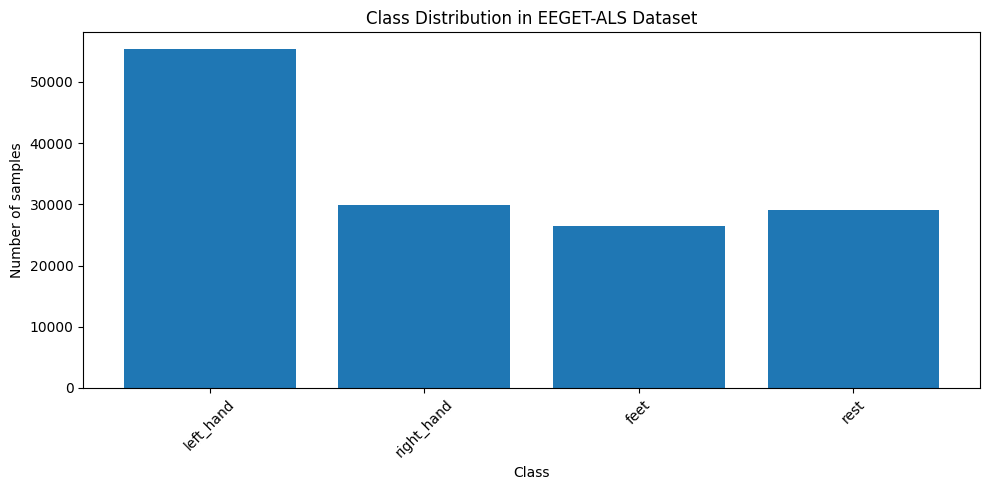

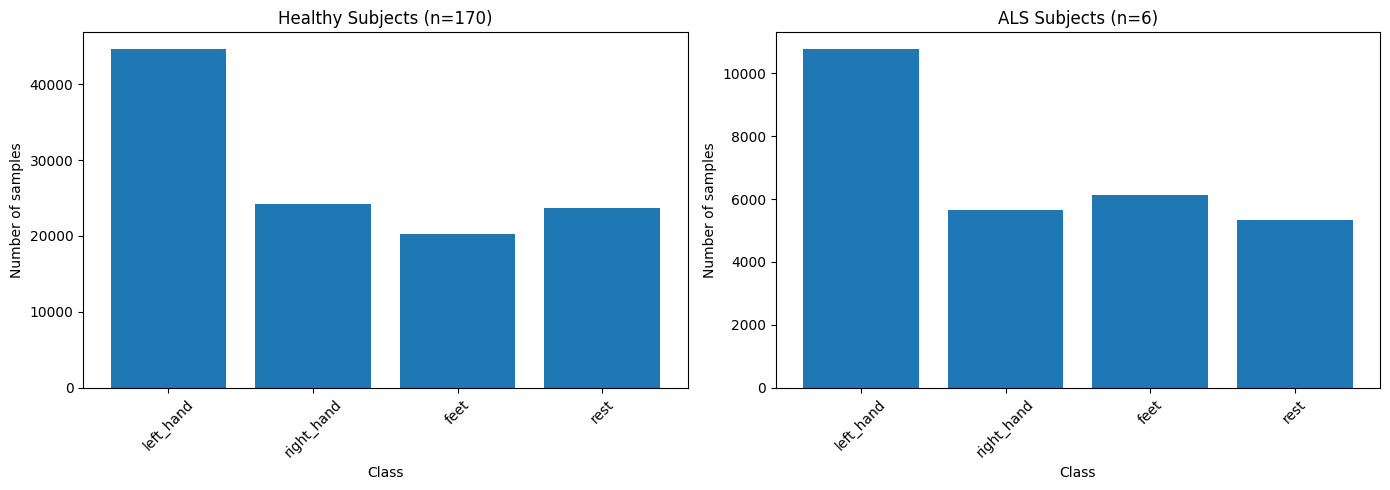

In [31]:
# Visualize class distribution
labels = CLASSES
print(f"{len(labels)} classes: {labels}")

# Distribution by class
plt.figure(figsize=(10, 5))
class_counts = [np.sum(y_all == i) for i in range(len(labels))]
plt.bar(labels, class_counts)
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.title('Class Distribution in EEGET-ALS Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Distribution by subject type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Healthy subjects distribution
healthy_class_counts = [np.sum(y_healthy == i) for i in range(len(labels))]
axes[0].bar(labels, healthy_class_counts)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of samples')
axes[0].set_title(f'Healthy Subjects (n={len(np.unique(subjects_healthy))})')
axes[0].tick_params(axis='x', rotation=45)

# ALS subjects distribution
als_class_counts = [np.sum(y_als == i) for i in range(len(labels))]
axes[1].bar(labels, als_class_counts)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Number of samples')
axes[1].set_title(f'ALS Subjects (n={len(np.unique(subjects_als))})')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

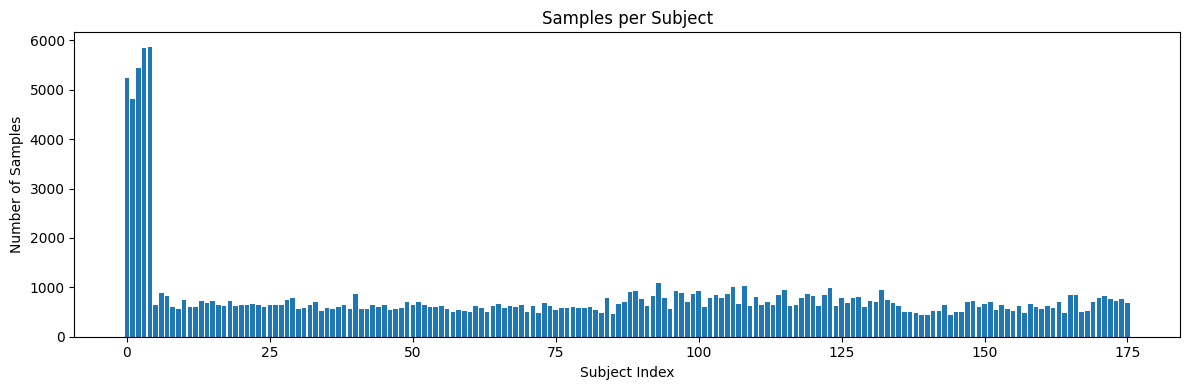

In [32]:
# Samples per subject distribution
samples_per_subject = ds_info.groupby('subject').size()
plt.figure(figsize=(12, 4))
plt.bar(range(len(samples_per_subject)), samples_per_subject.values)
plt.xlabel('Subject Index')
plt.ylabel('Number of Samples')
plt.title('Samples per Subject')
plt.tight_layout()
plt.show()

In [33]:
# Verify data shapes
print(f"X_all shape: {X_all.shape}")
print(f"y_all shape: {y_all.shape}")
print(f"subjects_all shape: {subjects_all.shape}")
print(f"\nUnique classes: {np.unique(y_all)}")
print(f"Class names: {label_encoder.classes_}")

X_all shape: (140622, 32, 256)
y_all shape: (140622,)
subjects_all shape: (140622,)

Unique classes: [0 1 2 3]
Class names: ['feet' 'left_hand' 'rest' 'right_hand']


In [34]:
# Define train/test subjects for EEGET-ALS
# Using subject-wise split to prevent data leakage
unique_subjects = np.unique(subjects_all)
n_subjects = len(unique_subjects)

# Split: 80% train, 20% test (by subjects)
np.random.seed(GLOBAL_SEED)
shuffled_subjects = np.random.permutation(unique_subjects)

n_test_subjects = max(1, int(0.2 * n_subjects))
test_subjects = set(shuffled_subjects[:n_test_subjects])
train_subjects = set(shuffled_subjects[n_test_subjects:])

print(f"Total subjects: {n_subjects}")
print(f"Train subjects: {len(train_subjects)}")
print(f"Test subjects: {len(test_subjects)}")
print(f"\nTest subjects: {sorted(test_subjects)[:10]}...")  # Show first 10

Total subjects: 176
Train subjects: 141
Test subjects: 35

Test subjects: [np.str_('id101'), np.str_('id104'), np.str_('id107'), np.str_('id108'), np.str_('id11'), np.str_('id110'), np.str_('id115'), np.str_('id12'), np.str_('id120'), np.str_('id121')]...


In [35]:
# Alternative: Load preprocessed data if saved previously
# You can save/load the preprocessed data using pickle

# Save preprocessed data (optional - run once)
# import pickle
# with open('eeget_als_preprocessed.pkl', 'wb') as f:
#     pickle.dump({
#         'X_all': X_all, 
#         'y_all': y_all, 
#         'subjects_all': subjects_all,
#         'label_encoder': label_encoder
#     }, f)

# # Load preprocessed data (faster for subsequent runs)
# with open('eeget_als_preprocessed.pkl', 'rb') as f:
#     data = pickle.load(f)
#     X_all = data['X_all']
#     y_all = data['y_all']
#     subjects_all = data['subjects_all']
#     label_encoder = data['label_encoder']

print("Data ready for training!")

Data ready for training!


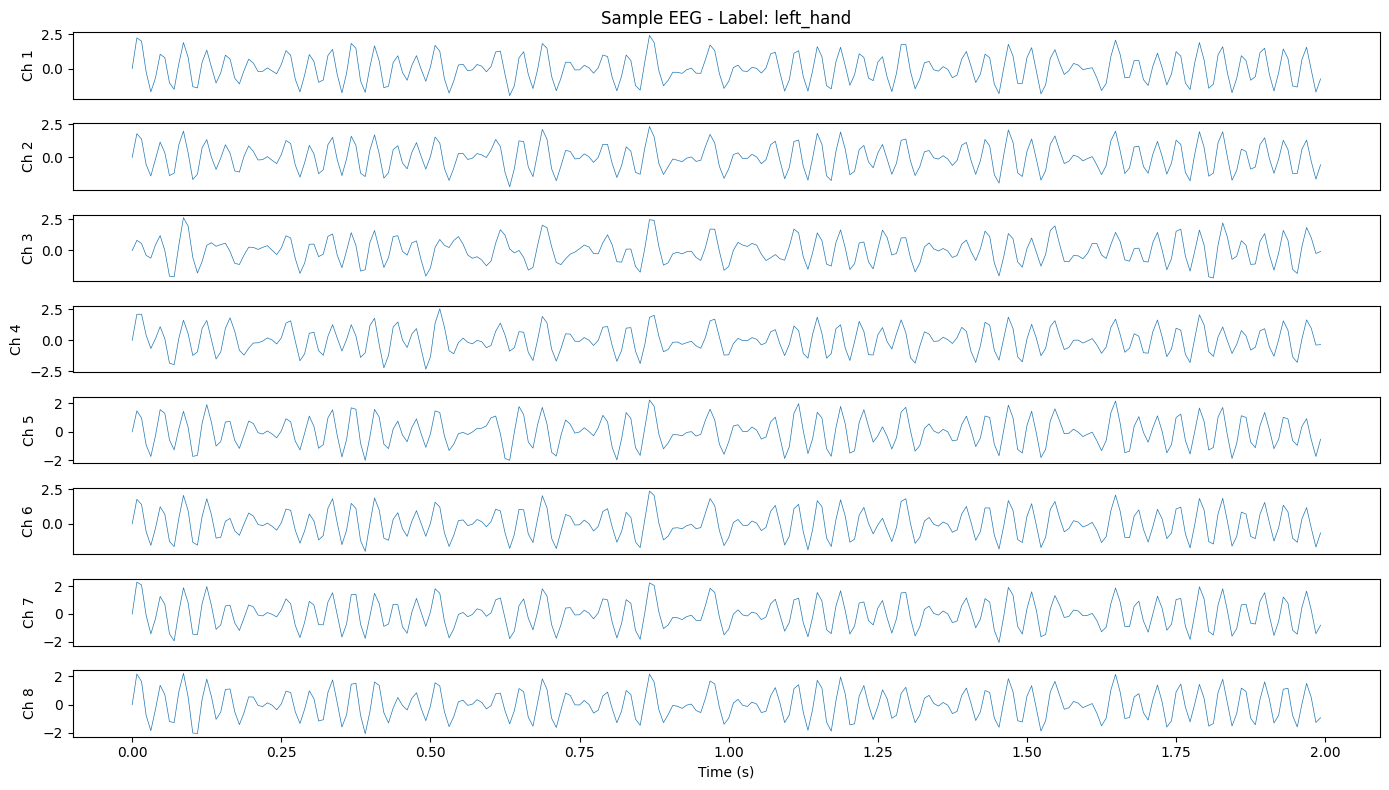

In [36]:
# Display sample EEG data
sample_idx = 0
sample_data = X_all[sample_idx]
sample_label = label_encoder.inverse_transform([y_all[sample_idx]])[0]

plt.figure(figsize=(14, 8))
time_axis = np.arange(sample_data.shape[1]) / SFREQ

# Plot first 8 channels
for i in range(min(8, N_CHANNELS)):
    plt.subplot(8, 1, i + 1)
    plt.plot(time_axis, sample_data[i, :], linewidth=0.5)
    plt.ylabel(f'Ch {i+1}')
    if i == 0:
        plt.title(f'Sample EEG - Label: {sample_label}')
    if i < 7:
        plt.xticks([])
        
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

In [37]:
# Train/Test Split Configuration
# Using subject-wise split to prevent data leakage

# Define class mapping for training
train_trials_map = {
    "left_hand": [0, 1, 2],
    "right_hand": [0, 1, 2],
    "feet": [0, 1, 2],
    "rest": [0, 1, 2],
}

# You can customize test subjects here
# Default: random 20% of subjects
# Or specify specific subjects:
# test_subjects = {'ALS01', 'ALS02', 'id10', 'id20', 'id30'}

# Option to include only certain subject types for testing
include_als_in_test = True  # Set to False to exclude ALS from test
include_healthy_in_test = True  # Set to False to exclude healthy from test

# Filter test subjects based on settings
filtered_test_subjects = set()
for s in test_subjects:
    if s.startswith('ALS') and include_als_in_test:
        filtered_test_subjects.add(s)
    elif s.startswith('id') and include_healthy_in_test:
        filtered_test_subjects.add(s)

test_subjects = filtered_test_subjects
print(f"Final test subjects ({len(test_subjects)}): {sorted(list(test_subjects))[:10]}...")

Final test subjects (35): [np.str_('id101'), np.str_('id104'), np.str_('id107'), np.str_('id108'), np.str_('id11'), np.str_('id110'), np.str_('id115'), np.str_('id12'), np.str_('id120'), np.str_('id121')]...


In [38]:
# Create train/validation/test splits
# Configuration
als_target_subject = None  # Set to e.g., "ALS01" for specific ALS subject experiments
remove_all_als_subjects = False  # Set to True to train only on healthy subjects
remove_other_als_subjects = False  # Set to True to keep only target ALS subject

# Create masks for train and test
train_mask = np.array([s not in test_subjects for s in subjects_all])
test_mask = np.array([s in test_subjects for s in subjects_all])

# Apply ALS removal settings if needed
if remove_all_als_subjects:
    als_mask_inv = np.array([not s.startswith('ALS') for s in subjects_all])
    train_mask = train_mask & als_mask_inv

# Split data
X_train = X_all[train_mask]
y_train = y_all[train_mask]
subjects_train = subjects_all[train_mask]

X_test = X_all[test_mask]
y_test = y_all[test_mask]
subjects_test = subjects_all[test_mask]

print(f"Training set: {X_train.shape[0]} samples from {len(np.unique(subjects_train))} subjects")
print(f"Test set: {X_test.shape[0]} samples from {len(np.unique(subjects_test))} subjects")

# Class distribution in splits
print("\nTraining class distribution:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls}: {np.sum(y_train == i)}")

print("\nTest class distribution:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls}: {np.sum(y_test == i)}")

Training set: 118380 samples from 141 subjects
Test set: 22242 samples from 35 subjects

Training class distribution:
  feet: 46445
  left_hand: 25147
  rest: 22297
  right_hand: 24491

Test class distribution:
  feet: 8898
  left_hand: 4665
  rest: 4153
  right_hand: 4526


In [39]:
# Visualize sample from a specific subject
sample_subject = np.unique(subjects_train)[0]  # First training subject

# Get indices for this subject
subject_indices = np.where(subjects_train == sample_subject)[0]
print(f"Sample subject: {sample_subject}")
print(f"Number of samples: {len(subject_indices)}")

# Get data for this subject
X_subject = X_train[subject_indices]
y_subject = y_train[subject_indices]

print(f"Subject data shape: {X_subject.shape}")
print(f"Class distribution for {sample_subject}:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls}: {np.sum(y_subject == i)}")

Sample subject: ALS01
Number of samples: 5239
Subject data shape: (5239, 32, 256)
Class distribution for ALS01:
  feet: 1992
  left_hand: 1103
  rest: 1133
  right_hand: 1011


In [40]:
# Create PyTorch datasets using the EEGDataset class defined earlier
# The EEGDataset class is already defined in the notebook

# Create training dataset
train_dataset = EEGDataset(
    X=X_train,
    Y=y_train,
    is_training=True,
    use_augmentation=True,
    use_normalization=True,
    rng_seed=GLOBAL_SEED
)

# Create test dataset
test_dataset = EEGDataset(
    X=X_test,
    Y=y_test,
    is_training=False,
    use_augmentation=False,
    use_normalization=True,
    rng_seed=GLOBAL_SEED
)

print(f"Training dataset: {len(train_dataset)} samples")
print(f"Test dataset: {len(test_dataset)} samples")
print(f"Class weights: {train_dataset.class_weight}")

Training dataset: 118380 samples
Test dataset: 22242 samples
Class weights: [0.6372053  1.17687995 1.32730861 1.20840309]


In [41]:
# Create DataLoaders
batch_size = 64  # @param

train_loader = td.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True if device.type == 'cuda' else False
)

test_loader = td.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True if device.type == 'cuda' else False
)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

# Sample batch
sample_batch = next(iter(train_loader))
print(f"\nSample batch X shape: {sample_batch[0].shape}")
print(f"Sample batch Y shape: {sample_batch[1].shape}")

Train batches: 1850
Test batches: 348

Sample batch X shape: torch.Size([64, 32, 256])
Sample batch Y shape: torch.Size([64])


In [42]:
# Prepare variables for the training functions in the notebook
# These variables are used by the existing training cells

# Model configuration
n_classes = N_CLASSES  # 4 classes
n_channels = N_CHANNELS  # 32 channels
n_samples = WINDOW_SAMPLES  # 256 samples (2 seconds at 128 Hz)

# Store subject info for each sample (for subject-wise evaluation later)
train_subjects_tensor = torch.tensor([hash(s) % 10000 for s in subjects_train])
test_subjects_tensor = torch.tensor([hash(s) % 10000 for s in subjects_test])

print(f"Model input shape: ({n_channels}, {n_samples})")
print(f"Number of classes: {n_classes}")
print(f"Classes: {CLASSES}")

Model input shape: (32, 256)
Number of classes: 4
Classes: ['left_hand', 'right_hand', 'feet', 'rest']


In [43]:
%%time
# Training configuration for EEGET-ALS dataset
exp = "EEGET_ALS"  # @param
exp += f"#{','.join(sorted(list(test_subjects))[:5])}..."  # Show first 5 test subjects

with_mcd = False  # @param {"type": "boolean"}

# Use variables from our new data loading
n_classes = N_CLASSES  # From cell 12: 4 classes
n_channels = N_CHANNELS  # From cell 12: 32 channels  
n_samples = WINDOW_SAMPLES  # From cell 12: 256 samples

pretrained_checkpoint = None  # @param - set to checkpoint path if you have one
reinit_clf = True  # @param {"type": "boolean"}
train_clf_only = False  # @param {"type": "boolean"}
use_augmentation = False  # @param {"type": "boolean"}
use_normalization = True  # @param {"type": "boolean"}
epochs = 150  # @param
batch_size = 64  # @param
lr = 3e-4  # @param
min_lr = 1e-4  # @param
use_lr_sch = False  # @param {"type": "boolean"}
pct_start = 0.1  # @param
weight_decay = 0.0  # @param
base_smooth_label = 0.0  # @param (for each class)
vae_loss_scale = 1.0  # @param
kld_betas_n_cycles = 10  # @param
kld_betas_ratio = 1.0  # @param
use_focal_loss = False  # @param {"type": "boolean"}
focal_loss_gamma = 2.0  # @param
use_class_weight = True  # @param {"type": "boolean"}
use_imbalanced_sampler = False  # @param {"type": "boolean"}
use_subject_sampler = False  # @param {"type": "boolean"}
src_loss_scale = 1.0  # @param
tgt_loss_scale = 1.0  # @param
mixup_alpha = 0.0  # @param
mixup_cross_label = False  # @param {"type": "boolean"}
drop_prob = 0.25  # @param
mcd_step_c_repeats = 5  # @param
monitor_val = "bac"  # @param
monitor_max_is_best = True  # @param {"type": "boolean"}
patience_epochs = 10  # @param
ckpt_dir = "./ckpt"  # @param
select_best_checkpoint = False  # @param
rng_seed = 42  # @param

pl.seed_everything(seed=rng_seed)

print(f"=== Training Configuration ===")
print(f"Experiment: {exp}")
print(f"Classes: {n_classes}, Channels: {n_channels}, Samples: {n_samples}")
print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"Epochs: {epochs}, Batch size: {batch_size}, LR: {lr}")

# Note: The do_training and do_training_with_mcd functions expect the old 
# braindecode dataset format. We need to use our PyTorch datasets instead.
# See the training cells below that use train_loader and test_loader directly.

print("\n⚠️ Note: Use the simplified training loop below instead of do_training()")
print("The do_training() function expects braindecode dataset format.")

Seed set to 42


=== Training Configuration ===
Experiment: EEGET_ALS#id101,id104,id107,id108,id11...
Classes: 4, Channels: 32, Samples: 256
Training samples: 118380, Test samples: 22242
Epochs: 150, Batch size: 64, LR: 0.0003

⚠️ Note: Use the simplified training loop below instead of do_training()
The do_training() function expects braindecode dataset format.
CPU times: user 5.3 ms, sys: 160 µs, total: 5.46 ms
Wall time: 10.2 ms


In [44]:
# Data Augmentation for EEG Data
# These can help improve model generalization

import numpy as np
import torch

class EEGAugmentation:
    """EEG-specific data augmentation techniques."""
    
    @staticmethod
    def add_gaussian_noise(x, std=0.1):
        """Add Gaussian noise to EEG signal."""
        noise = torch.randn_like(x) * std
        return x + noise
    
    @staticmethod
    def time_shift(x, shift_max=10):
        """Randomly shift signal in time."""
        shift = np.random.randint(-shift_max, shift_max + 1)
        if shift > 0:
            return torch.cat([torch.zeros_like(x[..., :shift]), x[..., :-shift]], dim=-1)
        elif shift < 0:
            return torch.cat([x[..., -shift:], torch.zeros_like(x[..., :(-shift)])], dim=-1)
        return x
    
    @staticmethod
    def channel_dropout(x, p=0.1):
        """Randomly zero out entire channels."""
        if x.dim() == 3:
            mask = (torch.rand(x.size(0), x.size(1), 1) > p).float().to(x.device)
        else:
            mask = (torch.rand(x.size(1), 1) > p).float().to(x.device)
        return x * mask
    
    @staticmethod  
    def amplitude_scale(x, scale_range=(0.8, 1.2)):
        """Randomly scale amplitude."""
        scale = torch.empty(1).uniform_(scale_range[0], scale_range[1]).to(x.device)
        return x * scale


class AugmentedDataset(torch.utils.data.Dataset):
    """Dataset wrapper that applies augmentation during training."""
    
    def __init__(self, X, y, augment=True, noise_std=0.1, shift_max=10, 
                 channel_dropout_p=0.1):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment
        self.noise_std = noise_std
        self.shift_max = shift_max
        self.channel_dropout_p = channel_dropout_p
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y[idx]
        
        if self.augment and self.training:
            # Apply augmentations with some probability
            if np.random.rand() < 0.5:
                x = EEGAugmentation.add_gaussian_noise(x, self.noise_std)
            if np.random.rand() < 0.3:
                x = EEGAugmentation.time_shift(x, self.shift_max)
            if np.random.rand() < 0.2:
                x = EEGAugmentation.channel_dropout(x, self.channel_dropout_p)
            if np.random.rand() < 0.5:
                x = EEGAugmentation.amplitude_scale(x)
        
        return x, y
    
    @property
    def training(self):
        return self._training if hasattr(self, '_training') else True
    
    @training.setter
    def training(self, value):
        self._training = value


# Check data statistics
print("="*60)
print("Data Statistics Check")
print("="*60)
print(f"\nX_train shape: {X_train.shape}")
print(f"X_train dtype: {X_train.dtype}")
print(f"X_train range: [{X_train.min():.4f}, {X_train.max():.4f}]")
print(f"X_train mean: {X_train.mean():.4f}")
print(f"X_train std: {X_train.std():.4f}")

print(f"\nClass distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls} ({CLASSES[cls]}): {cnt} samples ({100*cnt/len(y_train):.1f}%)")

print(f"\nClass distribution in test set:")
unique, counts = np.unique(y_test, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls} ({CLASSES[cls]}): {cnt} samples ({100*cnt/len(y_test):.1f}%)")

# Note: Augmentation is implemented but not used by default
# To use augmented dataset:
# train_dataset_aug = AugmentedDataset(X_train, y_train, augment=True)
# train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)

print("\n✓ Data augmentation utilities defined")
print("  Use AugmentedDataset for training with augmentation")

Data Statistics Check

X_train shape: (118380, 32, 256)
X_train dtype: float32
X_train range: [-10.3022, 10.9022]
X_train mean: 0.0000
X_train std: 1.0000

Class distribution in training set:
  Class 0 (left_hand): 46445 samples (39.2%)
  Class 1 (right_hand): 25147 samples (21.2%)
  Class 2 (feet): 22297 samples (18.8%)
  Class 3 (rest): 24491 samples (20.7%)

Class distribution in test set:
  Class 0 (left_hand): 8898 samples (40.0%)
  Class 1 (right_hand): 4665 samples (21.0%)
  Class 2 (feet): 4153 samples (18.7%)
  Class 3 (rest): 4526 samples (20.3%)

✓ Data augmentation utilities defined
  Use AugmentedDataset for training with augmentation


Creating ImprovedEEGNet model...
Model: ImprovedEEGNet
Total parameters: 2,132
Trainable parameters: 2,132

Model Architecture:
ImprovedEEGNet(
  (conv1): Conv2d(1, 8, kernel_size=(1, 64), stride=(1, 1), padding=same, bias=False)
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(8, 16, kernel_size=(32, 1), stride=(1, 1), groups=8, bias=False)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
  (drop1): Dropout(p=0.5, inplace=False)
  (conv3): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=same, groups=16, bias=False)
  (conv4): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
  (drop2): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=128, o

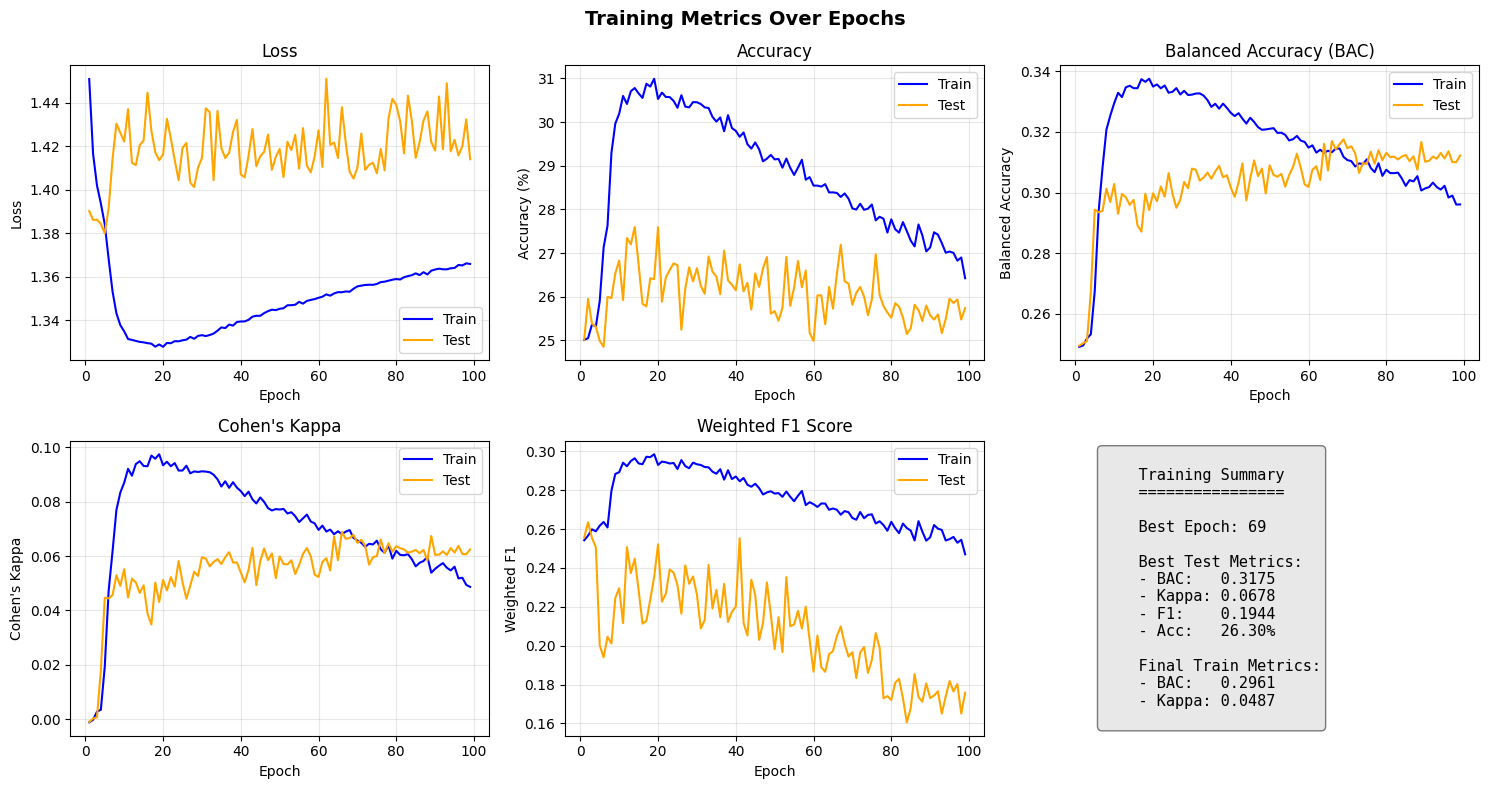

In [45]:
# Initialize and train the model with IMPROVED EEGNet architecture
# The previous SimpleEEGNet wasn't learning (40% = random chance for 4 classes)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingWarmRestarts
from sklearn.metrics import balanced_accuracy_score, cohen_kappa_score, f1_score

class ImprovedEEGNet(nn.Module):
    """
    Improved EEGNet for Motor Imagery Classification.
    Based on the original EEGNet paper by Lawhern et al. (2018)
    with modifications for 128Hz EEG data.
    """
    def __init__(self, n_channels=32, n_samples=256, n_classes=4, 
                 F1=8, D=2, F2=16, dropout=0.5):
        super().__init__()
        
        self.n_channels = n_channels
        self.n_samples = n_samples
        
        # Block 1: Temporal Convolution
        # Kernel size = half of sampling rate (64 for 128Hz)
        self.conv1 = nn.Conv2d(1, F1, (1, 64), padding='same', bias=False)
        self.bn1 = nn.BatchNorm2d(F1)
        
        # Block 1: Spatial Convolution (Depthwise)
        self.conv2 = nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False)
        self.bn2 = nn.BatchNorm2d(F1 * D)
        self.pool1 = nn.AvgPool2d((1, 4))
        self.drop1 = nn.Dropout(dropout)
        
        # Block 2: Separable Convolution
        # Depthwise convolution
        self.conv3 = nn.Conv2d(F1 * D, F1 * D, (1, 16), padding='same', groups=F1 * D, bias=False)
        # Pointwise convolution
        self.conv4 = nn.Conv2d(F1 * D, F2, (1, 1), bias=False)
        self.bn3 = nn.BatchNorm2d(F2)
        self.pool2 = nn.AvgPool2d((1, 8))
        self.drop2 = nn.Dropout(dropout)
        
        # Calculate output size after convolutions and pooling
        # After pool1: n_samples // 4, After pool2: n_samples // 32
        self.flatten_size = F2 * (n_samples // 32)
        
        # Classifier
        self.fc = nn.Linear(self.flatten_size, n_classes)
        
        # Initialize weights
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)
        
    def forward(self, x):
        # Input: (batch, channels, samples)
        if x.dim() == 3:
            x = x.unsqueeze(1)  # (batch, 1, channels, samples)
        
        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.elu(x)
        x = self.pool1(x)
        x = self.drop1(x)
        
        # Block 2
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.bn3(x)
        x = F.elu(x)
        x = self.pool2(x)
        x = self.drop2(x)
        
        # Classifier
        x = x.flatten(1)
        x = self.fc(x)
        return x


class DeepConvNet(nn.Module):
    """
    DeepConvNet for EEG classification.
    Alternative architecture that sometimes works better.
    """
    def __init__(self, n_channels=32, n_samples=256, n_classes=4, dropout=0.5):
        super().__init__()
        
        # Block 1
        self.conv1 = nn.Conv2d(1, 25, (1, 5), bias=False)
        self.conv2 = nn.Conv2d(25, 25, (n_channels, 1), bias=False)
        self.bn1 = nn.BatchNorm2d(25)
        self.pool1 = nn.MaxPool2d((1, 2))
        self.drop1 = nn.Dropout(dropout)
        
        # Block 2
        self.conv3 = nn.Conv2d(25, 50, (1, 5), bias=False)
        self.bn2 = nn.BatchNorm2d(50)
        self.pool2 = nn.MaxPool2d((1, 2))
        self.drop2 = nn.Dropout(dropout)
        
        # Block 3
        self.conv4 = nn.Conv2d(50, 100, (1, 5), bias=False)
        self.bn3 = nn.BatchNorm2d(100)
        self.pool3 = nn.MaxPool2d((1, 2))
        self.drop3 = nn.Dropout(dropout)
        
        # Block 4
        self.conv5 = nn.Conv2d(100, 200, (1, 5), bias=False)
        self.bn4 = nn.BatchNorm2d(200)
        self.pool4 = nn.MaxPool2d((1, 2))
        self.drop4 = nn.Dropout(dropout)
        
        # Calculate flatten size dynamically
        self._calc_flatten_size(n_channels, n_samples)
        
        # Classifier
        self.fc = nn.Linear(self.flatten_size, n_classes)
        
        self._initialize_weights()
        
    def _calc_flatten_size(self, n_channels, n_samples):
        x = torch.zeros(1, 1, n_channels, n_samples)
        x = self.pool1(F.elu(self.bn1(self.conv2(self.conv1(x)))))
        x = self.pool2(F.elu(self.bn2(self.conv3(x))))
        x = self.pool3(F.elu(self.bn3(self.conv4(x))))
        x = self.pool4(F.elu(self.bn4(self.conv5(x))))
        self.flatten_size = x.view(1, -1).size(1)
        
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)
        
    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(1)
        
        x = self.drop1(self.pool1(F.elu(self.bn1(self.conv2(self.conv1(x))))))
        x = self.drop2(self.pool2(F.elu(self.bn2(self.conv3(x)))))
        x = self.drop3(self.pool3(F.elu(self.bn3(self.conv4(x)))))
        x = self.drop4(self.pool4(F.elu(self.bn4(self.conv5(x)))))
        
        x = x.flatten(1)
        x = self.fc(x)
        return x


def train_model_improved(model, train_loader, test_loader, epochs=100, lr=1e-3, 
                        device='cuda', use_class_weights=True):
    """
    Improved training loop with BAC (Balanced Accuracy) and Kappa metrics.
    These metrics are used in the ALS Dataset paper for evaluation.
    """
    model = model.to(device)
    
    # Calculate class weights for imbalanced data
    if use_class_weights:
        all_labels = []
        for _, labels in train_loader:
            all_labels.extend(labels.numpy())
        class_counts = np.bincount(all_labels)
        class_weights = 1.0 / (class_counts + 1e-6)
        class_weights = class_weights / class_weights.sum() * len(class_counts)
        class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        print(f"Class weights: {class_weights.cpu().numpy()}")
    else:
        criterion = nn.CrossEntropyLoss()
    
    # Use AdamW with proper weight decay
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    
    # OneCycleLR for better convergence
    scheduler = OneCycleLR(
        optimizer, 
        max_lr=lr,
        epochs=epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.1,
        anneal_strategy='cos'
    )
    
    best_bac = 0.0  # Track best balanced accuracy
    best_model_state = None
    patience = 30
    patience_counter = 0
    
    # Extended history with BAC and Kappa
    history = {
        'train_loss': [], 'train_acc': [], 'train_bac': [], 'train_kappa': [], 'train_f1': [],
        'test_loss': [], 'test_acc': [], 'test_bac': [], 'test_kappa': [], 'test_f1': []
    }
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        train_preds, train_labels = [], []
        
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_preds.extend(predicted.cpu().numpy())
            train_labels.extend(batch_y.cpu().numpy())
        
        # Calculate training metrics
        train_acc = 100. * np.mean(np.array(train_preds) == np.array(train_labels))
        train_bac = balanced_accuracy_score(train_labels, train_preds)
        train_kappa = cohen_kappa_score(train_labels, train_preds)
        train_f1 = f1_score(train_labels, train_preds, average='weighted')
        
        # Evaluation
        model.eval()
        test_loss = 0
        test_preds, test_labels = [], []
        
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                test_preds.extend(predicted.cpu().numpy())
                test_labels.extend(batch_y.cpu().numpy())
        
        # Calculate test metrics
        test_acc = 100. * np.mean(np.array(test_preds) == np.array(test_labels))
        test_bac = balanced_accuracy_score(test_labels, test_preds)
        test_kappa = cohen_kappa_score(test_labels, test_preds)
        test_f1 = f1_score(test_labels, test_preds, average='weighted')
        
        # Store history
        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(train_acc)
        history['train_bac'].append(train_bac)
        history['train_kappa'].append(train_kappa)
        history['train_f1'].append(train_f1)
        history['test_loss'].append(test_loss / len(test_loader))
        history['test_acc'].append(test_acc)
        history['test_bac'].append(test_bac)
        history['test_kappa'].append(test_kappa)
        history['test_f1'].append(test_f1)
        
        # Early stopping based on BAC (better for imbalanced data)
        if test_bac > best_bac:
            best_bac = test_bac
            best_kappa = test_kappa
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f'Epoch {epoch+1:3d}/{epochs} | '
                  f'Loss: {train_loss/len(train_loader):.4f} | '
                  f'Train BAC: {train_bac:.4f}, Kappa: {train_kappa:.4f} | '
                  f'Test BAC: {test_bac:.4f}, Kappa: {test_kappa:.4f} | '
                  f'Best BAC: {best_bac:.4f}')
        
        # Early stopping
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    # Final evaluation
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    
    # Final metrics
    final_acc = 100. * np.mean(np.array(all_preds) == np.array(all_labels))
    final_bac = balanced_accuracy_score(all_labels, all_preds)
    final_kappa = cohen_kappa_score(all_labels, all_preds)
    final_f1 = f1_score(all_labels, all_preds, average='weighted')
    
    print(f'\n{"="*60}')
    print(f'=== Final Results (Best Model) ===')
    print(f'{"="*60}')
    print(f'Accuracy:              {final_acc:.2f}%')
    print(f'Balanced Accuracy (BAC): {final_bac:.4f}')
    print(f"Cohen's Kappa:         {final_kappa:.4f}")
    print(f'Weighted F1 Score:     {final_f1:.4f}')
    
    # Classification report
    from sklearn.metrics import classification_report, confusion_matrix
    print(f'\n{"="*60}')
    print(f'Classification Report:')
    print(f'{"="*60}')
    print(classification_report(all_labels, all_preds, target_names=CLASSES))
    
    print(f'\nConfusion Matrix:')
    cm = confusion_matrix(all_labels, all_preds)
    print(cm)
    
    # Plot training curves
    plot_training_curves(history)
    
    return model, history


def plot_training_curves(history):
    """Plot training curves for all metrics including BAC and Kappa."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    epochs_range = range(1, len(history['train_loss']) + 1)
    
    # Loss
    ax = axes[0, 0]
    ax.plot(epochs_range, history['train_loss'], label='Train', color='blue')
    ax.plot(epochs_range, history['test_loss'], label='Test', color='orange')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Accuracy
    ax = axes[0, 1]
    ax.plot(epochs_range, history['train_acc'], label='Train', color='blue')
    ax.plot(epochs_range, history['test_acc'], label='Test', color='orange')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Balanced Accuracy (BAC)
    ax = axes[0, 2]
    ax.plot(epochs_range, history['train_bac'], label='Train', color='blue')
    ax.plot(epochs_range, history['test_bac'], label='Test', color='orange')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Balanced Accuracy')
    ax.set_title('Balanced Accuracy (BAC)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Cohen's Kappa
    ax = axes[1, 0]
    ax.plot(epochs_range, history['train_kappa'], label='Train', color='blue')
    ax.plot(epochs_range, history['test_kappa'], label='Test', color='orange')
    ax.set_xlabel('Epoch')
    ax.set_ylabel("Cohen's Kappa")
    ax.set_title("Cohen's Kappa")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # F1 Score
    ax = axes[1, 1]
    ax.plot(epochs_range, history['train_f1'], label='Train', color='blue')
    ax.plot(epochs_range, history['test_f1'], label='Test', color='orange')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Weighted F1')
    ax.set_title('Weighted F1 Score')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Summary text
    ax = axes[1, 2]
    ax.axis('off')
    
    # Get best values
    best_epoch = np.argmax(history['test_bac']) + 1
    summary_text = f"""
    Training Summary
    ================
    
    Best Epoch: {best_epoch}
    
    Best Test Metrics:
    - BAC:   {max(history['test_bac']):.4f}
    - Kappa: {history['test_kappa'][best_epoch-1]:.4f}
    - F1:    {history['test_f1'][best_epoch-1]:.4f}
    - Acc:   {history['test_acc'][best_epoch-1]:.2f}%
    
    Final Train Metrics:
    - BAC:   {history['train_bac'][-1]:.4f}
    - Kappa: {history['train_kappa'][-1]:.4f}
    """
    ax.text(0.1, 0.5, summary_text, transform=ax.transAxes, fontsize=11,
            verticalalignment='center', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))
    
    plt.suptitle('Training Metrics Over Epochs', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ============================================================
# Create and train the model
# ============================================================
print("="*60)
print("Creating ImprovedEEGNet model...")
print("="*60)

# Use ImprovedEEGNet (recommended for EEG motor imagery)
model = ImprovedEEGNet(
    n_channels=n_channels, 
    n_samples=n_samples, 
    n_classes=n_classes, 
    F1=8,      # Number of temporal filters
    D=2,       # Depth multiplier for spatial filters
    F2=16,     # Number of pointwise filters
    dropout=0.5  # Higher dropout for regularization
)

# Alternative: Try DeepConvNet if EEGNet doesn't work well
# model = DeepConvNet(n_channels=n_channels, n_samples=n_samples, n_classes=n_classes, dropout=0.5)

print(f"Model: {model.__class__.__name__}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Print model architecture
print(f"\nModel Architecture:")
print(model)

print(f"\n{'='*60}")
print(f"Starting training...")
print(f"{'='*60}")
print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")
print(f"Epochs: {epochs}, Learning Rate: {lr}")

# Train with improved loop
trained_model, history = train_model_improved(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=epochs,
    lr=1e-3,  # Higher initial LR with OneCycleLR
    device=device,
    use_class_weights=True
)

In [46]:
# Load checkpoint (optional - uncomment when you have a trained model)
# with_mcd = False  # @param {"type": "boolean"}

# ckpt_dir = "./ckpt/your_experiment_name/run01"  # @param - update this path
# select_best_checkpoint = True  # @param

# if os.path.exists(ckpt_dir):
#     if with_mcd:
#         module = MotorImageryWithMCDModule(
#             n_classes=n_classes,
#             n_channels=n_channels,
#             n_samples=n_samples,
#         )
#     else:
#         module = MotorImageryModule(
#             n_classes=n_classes,
#             n_channels=n_channels,
#             n_samples=n_samples,
#         )
    
#     checkpoint_path = f"{ckpt_dir}/{'best' if select_best_checkpoint else 'last'}.ckpt"
#     print(f"Loading checkpoint from {checkpoint_path}...")
#     module.load_state_dict(torch.load(checkpoint_path, map_location=device)["state_dict"])
#     module.to(device)
#     module.eval()
# else:
#     print(f"Checkpoint directory not found: {ckpt_dir}")

print("Checkpoint loading cell ready - uncomment when you have a trained model")

Checkpoint loading cell ready - uncomment when you have a trained model


Visualizing trained model weights...


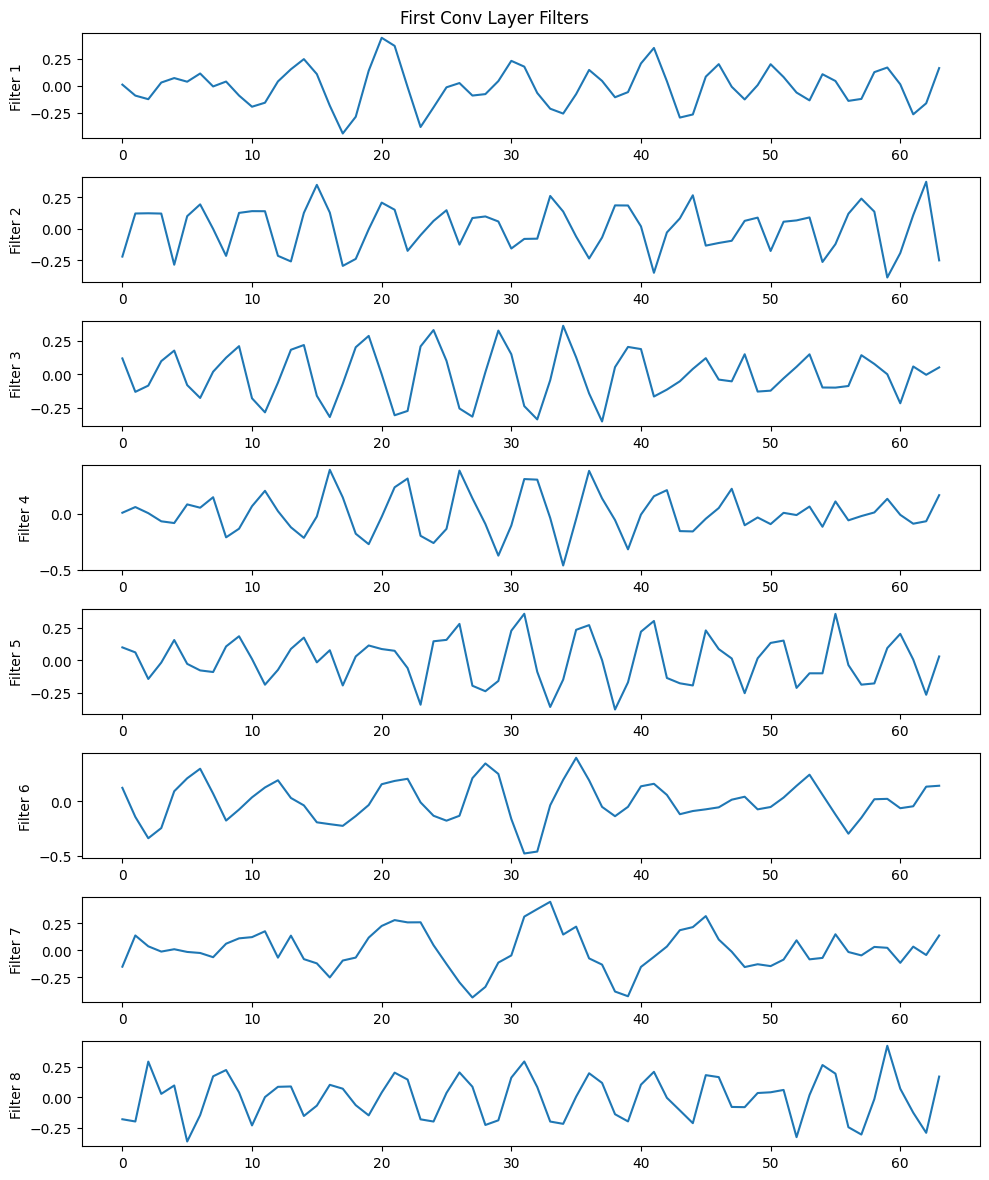

In [47]:
# Visualize model weights (only run after training)
# This cell visualizes the trained model's convolutional filters

if 'trained_model' in dir():
    # Visualize the first layer weights
    print("Visualizing trained model weights...")
    
    # Get first conv layer weights
    first_conv = None
    for name, module in trained_model.named_modules():
        if isinstance(module, nn.Conv2d):
            first_conv = module
            break
    
    if first_conv is not None:
        weights = first_conv.weight.detach().cpu().numpy()
        n_filters = min(weights.shape[0], 8)
        
        fig, axes = plt.subplots(nrows=n_filters, ncols=1, figsize=(10, n_filters * 1.5))
        if n_filters == 1:
            axes = [axes]
            
        for i in range(n_filters):
            w = weights[i].flatten()
            axes[i].plot(w)
            axes[i].set_ylabel(f'Filter {i+1}')
        
        plt.suptitle('First Conv Layer Filters')
        plt.tight_layout()
        plt.show()
    else:
        print("No Conv2d layer found in model")
else:
    print("No trained model found. Run training first.")

In [48]:
# Create MNE Epochs object from numpy array for visualization
# This is optional - useful for topographic plots

# Define channel names (standard 10-20 system for 32 channels)
channel_names = [
    'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8',
    'FC5', 'FC1', 'FC2', 'FC6',
    'T7', 'C3', 'Cz', 'C4', 'T8',
    'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8',
    'PO7', 'PO3', 'PO4', 'PO8',
    'O1', 'Oz', 'O2'
]

# Create info object
if len(channel_names) == N_CHANNELS:
    info = mne.create_info(ch_names=channel_names, sfreq=SFREQ, ch_types='eeg')
    
    # Create epochs from a subset of data
    sample_epochs = mne.EpochsArray(X_all[:100], info)  # First 100 samples
    sample_epochs.set_montage('standard_1005', on_missing='ignore')
    
    print(f"Created MNE Epochs object with {len(sample_epochs)} epochs")
    # sample_epochs.plot_psd_topomap()  # Uncomment to plot
else:
    print(f"Channel names ({len(channel_names)}) don't match N_CHANNELS ({N_CHANNELS})")

Not setting metadata
100 matching events found
No baseline correction applied
0 projection items activated
Created MNE Epochs object with 100 epochs


Using MNE info with 32 channels
Model type: ImprovedEEGNet
Spatial filter shape: (16, 1, 32, 1)


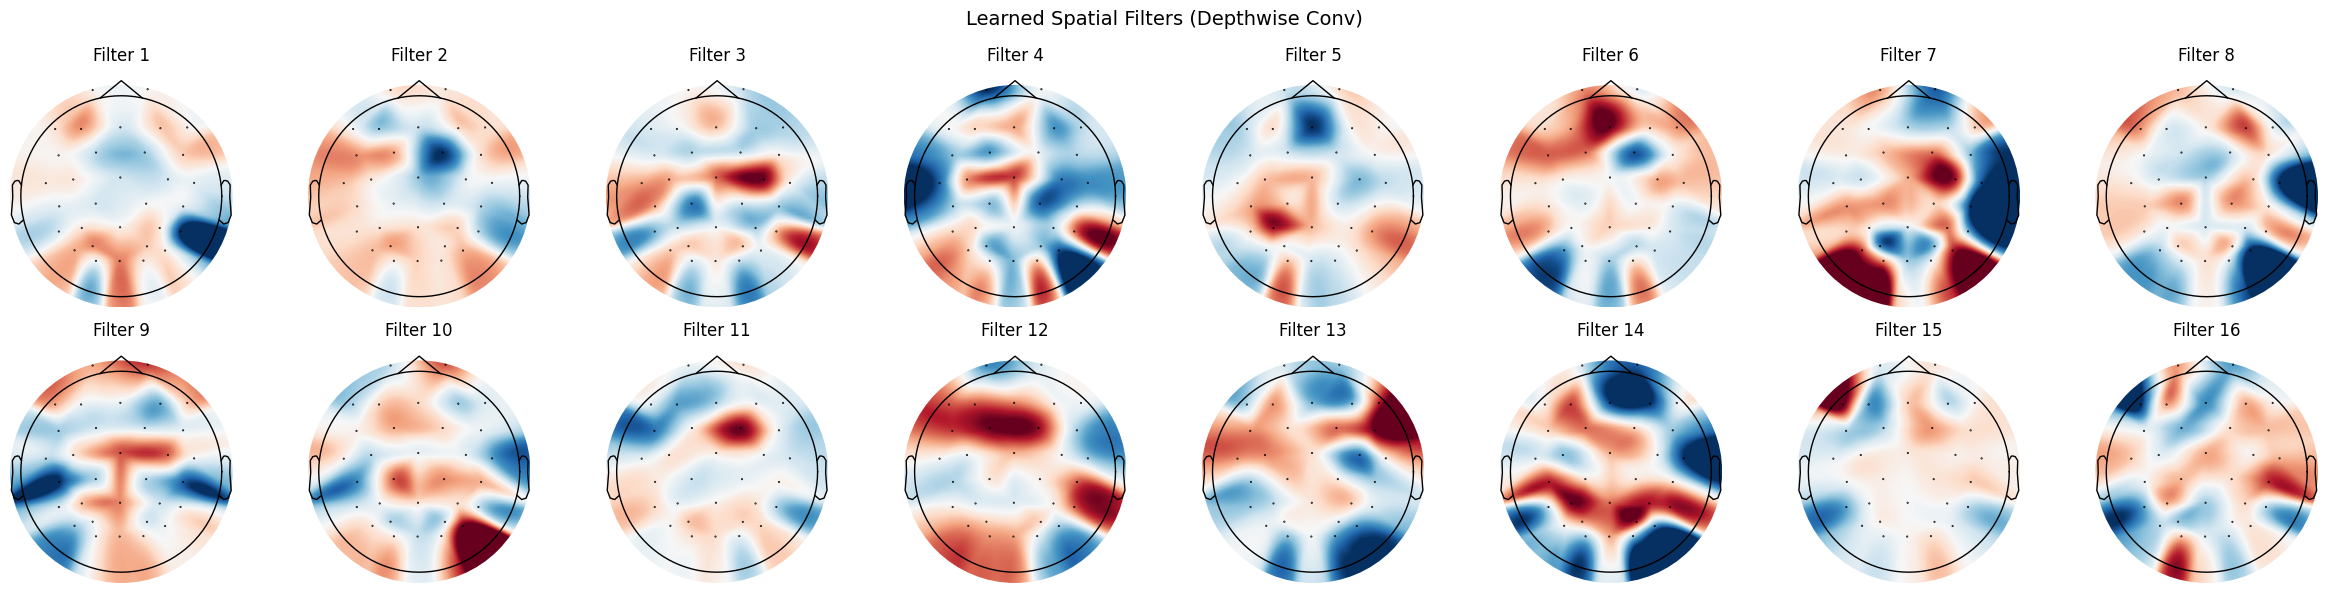

In [49]:
# Visualize convolutional filter weights as topomaps
# Note: This requires a model with spatial convolutions and MNE epochs object

# Check if we have the necessary objects
if 'sample_epochs' in dir() and sample_epochs is not None:
    info = sample_epochs.info
    print(f"Using MNE info with {len(info['ch_names'])} channels")
else:
    # Create info from scratch if sample_epochs doesn't exist
    channel_names = [
        'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8',
        'FC5', 'FC1', 'FC2', 'FC6',
        'T7', 'C3', 'Cz', 'C4', 'T8',
        'CP5', 'CP1', 'CP2', 'CP6',
        'P7', 'P3', 'Pz', 'P4', 'P8',
        'PO7', 'PO3', 'PO4', 'PO8',
        'O1', 'Oz', 'O2'
    ]
    info = mne.create_info(ch_names=channel_names, sfreq=SFREQ, ch_types='eeg')
    # Set montage for topographic plotting
    montage = mne.channels.make_standard_montage('standard_1005')
    info.set_montage(montage, on_missing='ignore')
    print(f"Created MNE info with {len(channel_names)} channels")

# Check if trained_model exists and has the right structure
if 'trained_model' in dir() and trained_model is not None:
    print(f"Model type: {type(trained_model).__name__}")
    
    # Try to visualize spatial filter weights
    # For ImprovedEEGNet: conv2 is the spatial convolution (n_channels, 1)
    if hasattr(trained_model, 'conv2'):
        try:
            fig, axes = plt.subplots(nrows=2, ncols=8, figsize=(24, 6))
            axes = axes.flatten()
            
            # Get spatial filter weights
            with torch.no_grad():
                # conv2 shape: (F1*D, F1, n_channels, 1) for depthwise conv
                w = trained_model.conv2.weight.detach().cpu().numpy()
                print(f"Spatial filter shape: {w.shape}")
                
                n_filters = min(w.shape[0], 16)  # Show up to 16 filters
                
                for i in range(n_filters):
                    ax = axes[i]
                    # Extract filter weights for each spatial filter
                    filter_weights = w[i, 0, :, 0]  # (n_channels,)
                    
                    if len(filter_weights) == len(info['ch_names']):
                        mne.viz.plot_topomap(
                            filter_weights, info, axes=ax, 
                            show=False, contours=0
                        )
                        ax.set_title(f"Filter {i+1}")
                    else:
                        ax.text(0.5, 0.5, f"Filter {i+1}\nSize mismatch", 
                               ha='center', va='center', transform=ax.transAxes)
                        ax.axis('off')
                
                # Turn off unused axes
                for i in range(n_filters, len(axes)):
                    axes[i].axis('off')
                
                plt.suptitle('Learned Spatial Filters (Depthwise Conv)', fontsize=14)
                plt.tight_layout()
                plt.show()
                
        except Exception as e:
            print(f"Could not visualize spatial filters: {e}")
    else:
        print("Model doesn't have conv2 (spatial convolution layer)")
        print("Available layers:", [name for name, _ in trained_model.named_modules()])
else:
    print("No trained_model found. Run training first.")

In [50]:
# Prepare data for visualization
# Use X_all if available, otherwise use test data

if 'X_all' in dir() and 'y_all' in dir():
    X = X_all
    Y = y_all
    print(f"Using X_all: {X.shape}")
elif 'X_test' in dir() and 'y_test' in dir():
    X = X_test
    Y = y_test
    print(f"Using X_test: {X.shape}")
elif 'X_train' in dir() and 'y_train' in dir():
    X = X_train
    Y = y_train
    print(f"Using X_train: {X.shape}")
else:
    print("No data available! Please run data loading cells first.")
    X = None
    Y = None

if X is not None:
    print(f"Data shape: {X.shape}")
    print(f"Labels shape: {Y.shape}")
    print(f"Unique labels: {np.unique(Y)}")

Using X_all: (140622, 32, 256)
Data shape: (140622, 32, 256)
Labels shape: (140622,)
Unique labels: [0 1 2 3]


Feature shape: (200, 16, 64)


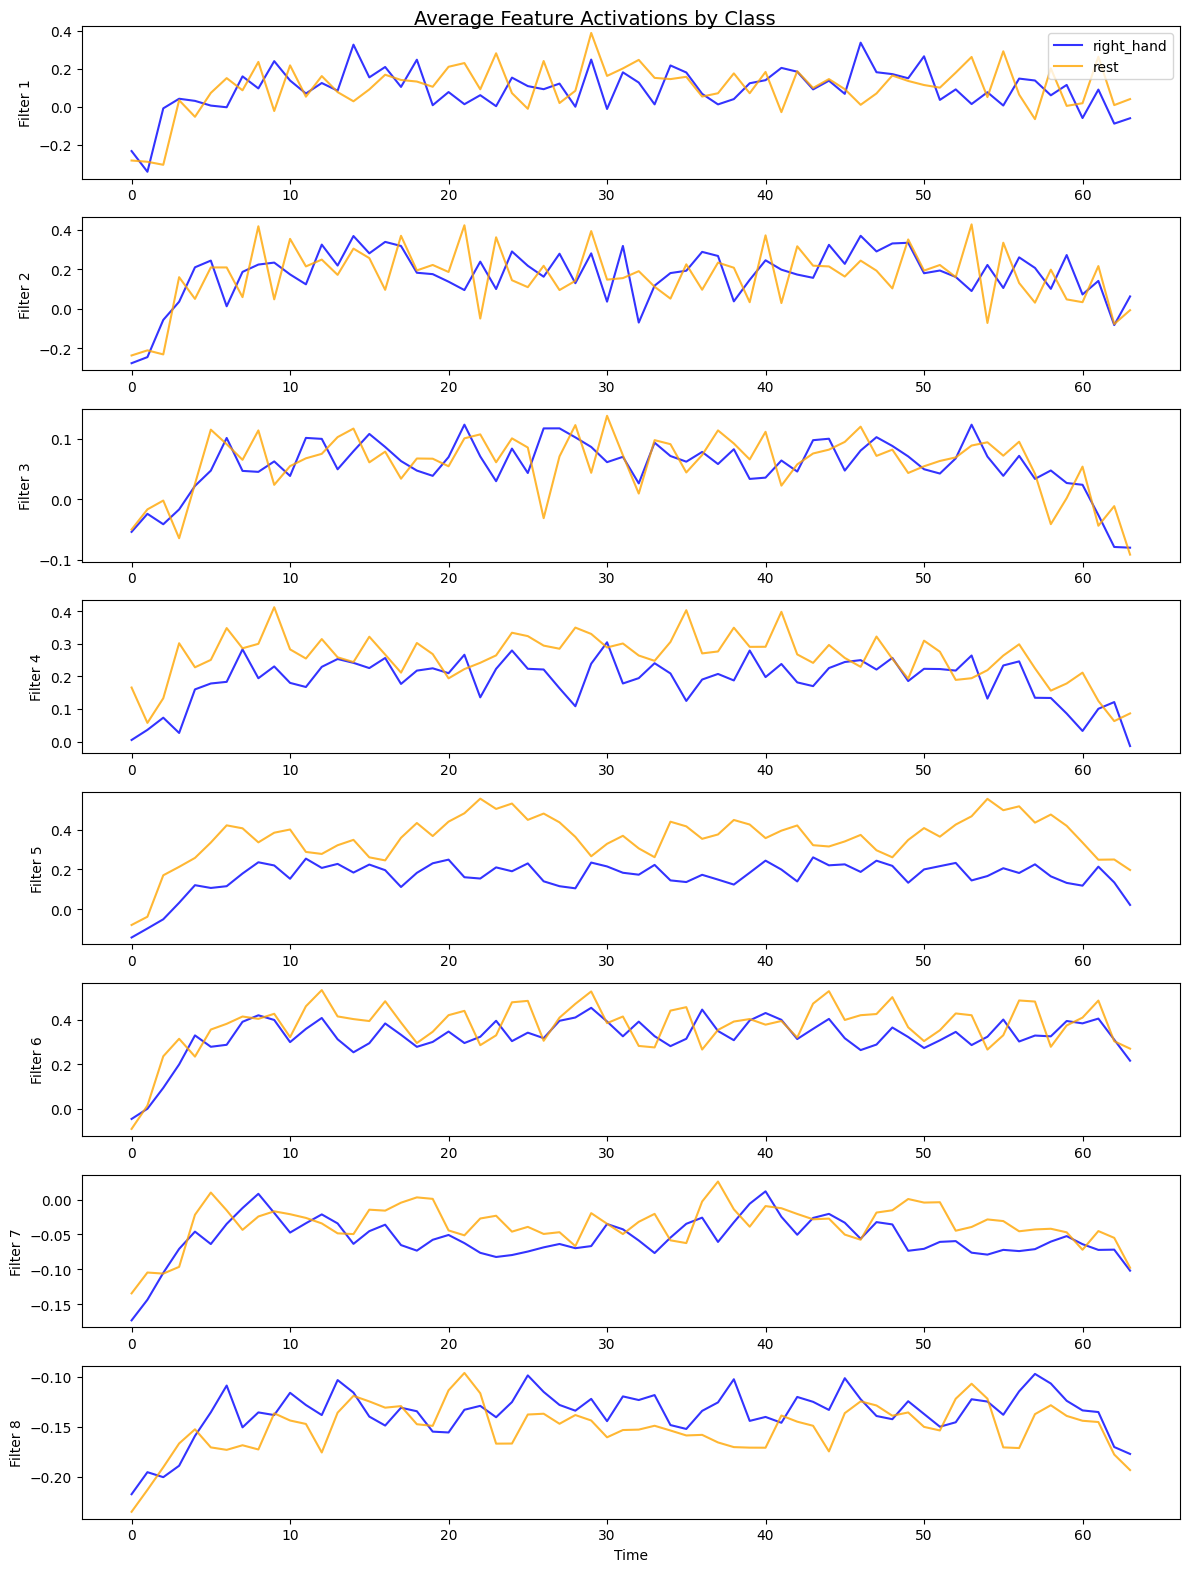

In [51]:
# Visualize feature activations per class
# This cell shows how different classes activate the model's intermediate features

# Check if we have data and model
if 'X_test' not in dir() or 'y_test' not in dir():
    print("X_test and y_test not found. Using X_train and y_train instead.")
    if 'X_train' in dir() and 'y_train' in dir():
        X_vis = X_train[:200]  # Use subset
        Y_vis = y_train[:200]
    else:
        print("No data available for visualization!")
        X_vis, Y_vis = None, None
else:
    X_vis = X_test[:200]
    Y_vis = y_test[:200]

if X_vis is not None and 'trained_model' in dir() and trained_model is not None:
    # Convert to tensor
    x = torch.tensor(X_vis, dtype=torch.float32).to(device)
    
    # Add channel dimension if needed: (batch, channels, samples) -> (batch, 1, channels, samples)
    if x.dim() == 3:
        x = x.unsqueeze(1)
    
    trained_model.eval()
    
    # Get intermediate features after first conv blocks
    with torch.no_grad():
        # For ImprovedEEGNet architecture
        if hasattr(trained_model, 'conv1') and hasattr(trained_model, 'bn1'):
            # Block 1
            feat = trained_model.conv1(x)
            feat = trained_model.bn1(feat)
            feat = trained_model.conv2(feat)
            feat = trained_model.bn2(feat)
            feat = F.elu(feat)
            feat = trained_model.pool1(feat)
            
            # Get feature representation (average over spatial dim)
            feat = feat.mean(dim=2).detach().cpu().numpy()  # (batch, filters, time)
            
            print(f"Feature shape: {feat.shape}")
            
            # Plot feature activations per class
            n_filters = min(feat.shape[1], 8)
            fig, axes = plt.subplots(nrows=n_filters, ncols=1, figsize=(12, n_filters * 2))
            if n_filters == 1:
                axes = [axes]
            
            colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink']
            class_names = CLASSES if 'CLASSES' in dir() else [f'Class {i}' for i in range(N_CLASSES)]
            
            for j in range(n_filters):
                ax = axes[j]
                for i, cls in enumerate(np.unique(Y_vis)):
                    cls_mask = Y_vis == cls
                    cls_feat = feat[cls_mask, j, :].mean(axis=0)
                    ax.plot(cls_feat, color=colors[i % len(colors)], 
                           label=class_names[cls] if j == 0 else "", alpha=0.8)
                ax.set_ylabel(f'Filter {j+1}')
                ax.set_xlabel('Time' if j == n_filters - 1 else '')
            
            axes[0].legend(loc='upper right')
            plt.suptitle('Average Feature Activations by Class', fontsize=14)
            plt.tight_layout()
            plt.show()
        else:
            print("Model architecture not compatible with this visualization")
            print(f"Model type: {type(trained_model).__name__}")
else:
    print("Cannot visualize: missing X_vis data or trained_model")

Feature shape for t-SNE: (500, 128)
Running 2D t-SNE...


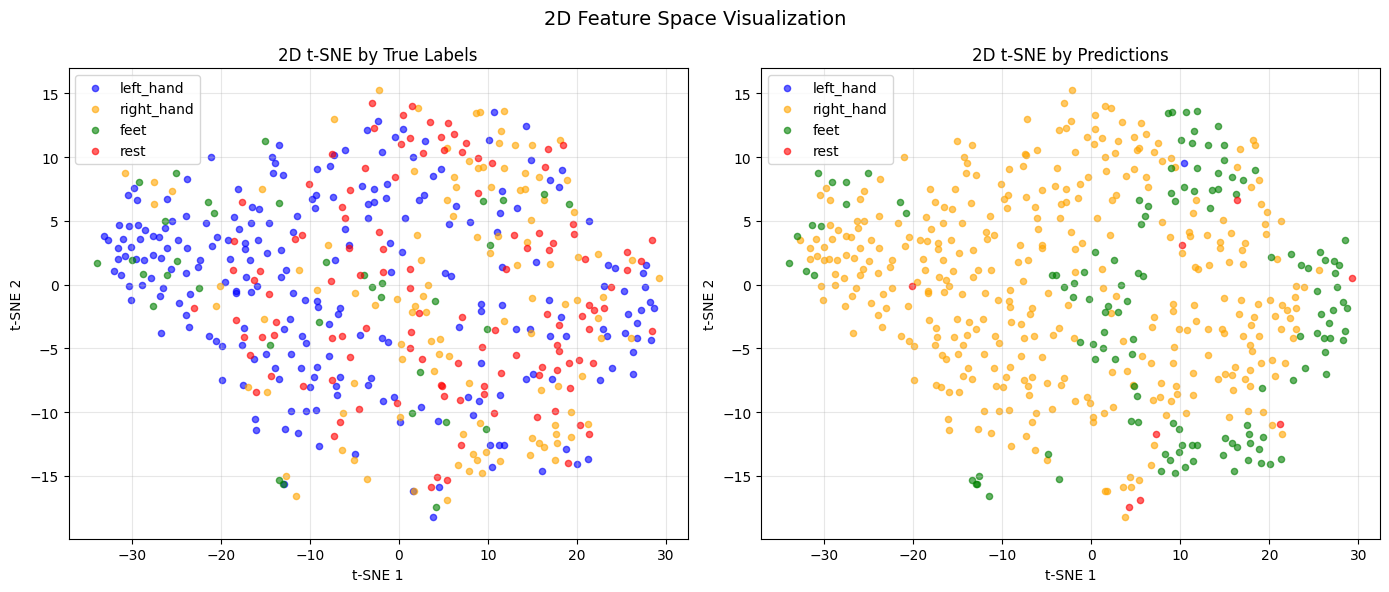

Running 3D t-SNE...


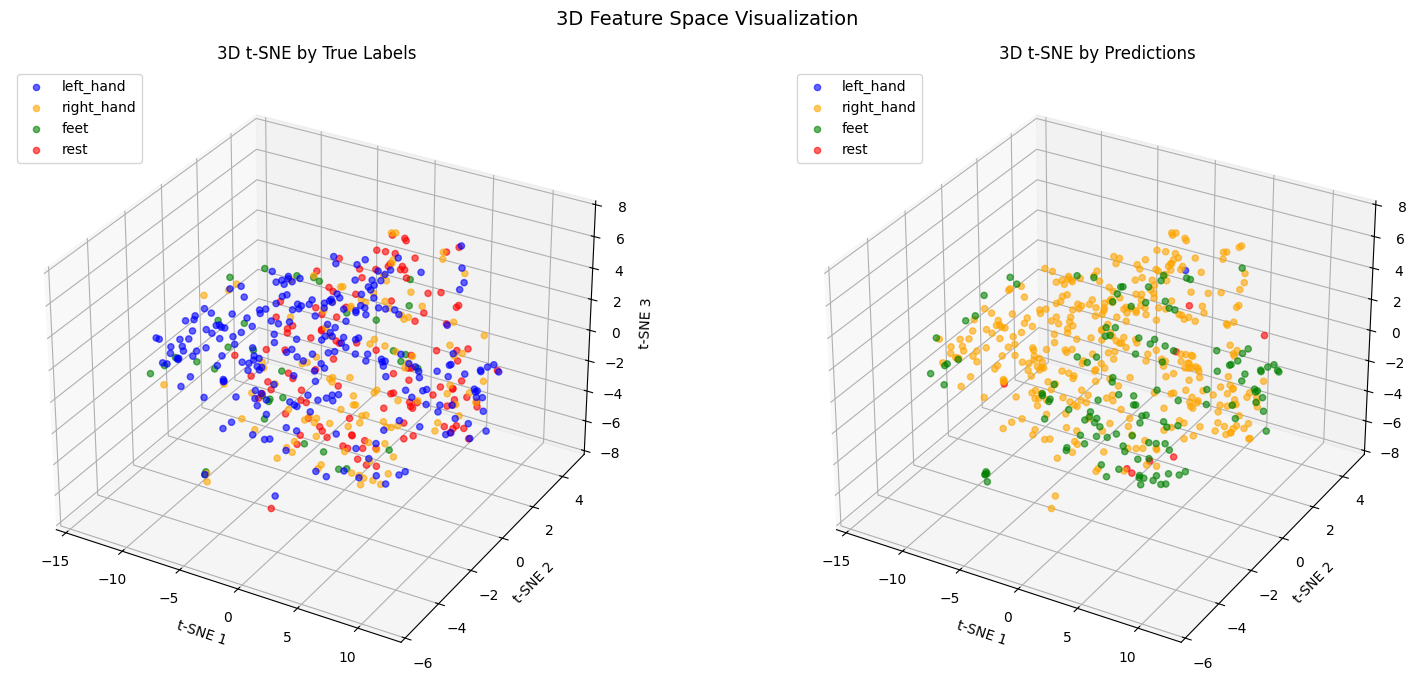

Creating interactive 3D plots with Plotly...



Accuracy on visualization subset: 14.20%
Number of samples: 500


In [52]:
# t-SNE Visualization of Learned Features (2D and 3D)
# This shows how well the model separates different classes in feature space

from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

# Check if we have data and model
if 'X_test' not in dir() or 'y_test' not in dir():
    print("Using X_train and y_train for visualization")
    if 'X_train' in dir() and 'y_train' in dir():
        X_vis = X_train[:500]  # Use subset for t-SNE (it's slow)
        Y_vis = y_train[:500]
    else:
        print("No data available!")
        X_vis, Y_vis = None, None
else:
    X_vis = X_test[:500]
    Y_vis = y_test[:500]

if X_vis is not None and 'trained_model' in dir() and trained_model is not None:
    # Convert to tensor
    x = torch.tensor(X_vis, dtype=torch.float32).to(device)
    
    # Add channel dimension if needed
    if x.dim() == 3:
        x = x.unsqueeze(1)
    
    trained_model.eval()
    
    with torch.no_grad():
        # Get features before final classifier
        # For ImprovedEEGNet, we extract features after the last dropout
        if hasattr(trained_model, 'conv1'):
            # Forward through all layers except fc
            feat = trained_model.conv1(x)
            feat = trained_model.bn1(feat)
            feat = trained_model.conv2(feat)
            feat = trained_model.bn2(feat)
            feat = F.elu(feat)
            feat = trained_model.pool1(feat)
            feat = trained_model.drop1(feat)
            
            feat = trained_model.conv3(feat)
            feat = trained_model.conv4(feat)
            feat = trained_model.bn3(feat)
            feat = F.elu(feat)
            feat = trained_model.pool2(feat)
            feat = trained_model.drop2(feat)
            
            # Flatten
            feat = feat.flatten(1)
            
            # Get predictions
            logits = trained_model.fc(feat)
            pred = torch.argmax(logits, dim=1)
            
            feat = feat.detach().cpu().numpy()
            pred = pred.detach().cpu().numpy()
            
            print(f"Feature shape for t-SNE: {feat.shape}")
            
            colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink']
            class_names = CLASSES if 'CLASSES' in dir() else [f'Class {i}' for i in range(N_CLASSES)]
            
            # ==========================================
            # 2D t-SNE
            # ==========================================
            print("Running 2D t-SNE...")
            tsne_2d = TSNE(n_components=2, random_state=42, perplexity=min(30, len(feat)-1))
            feat_2d = tsne_2d.fit_transform(feat)
            
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))
            
            # Plot by true labels (2D)
            ax = axes[0]
            for i, cls in enumerate(np.unique(Y_vis)):
                mask = Y_vis == cls
                ax.scatter(feat_2d[mask, 0], feat_2d[mask, 1], 
                          c=colors[i % len(colors)], label=class_names[cls], alpha=0.6, s=20)
            ax.set_title('2D t-SNE by True Labels')
            ax.legend()
            ax.set_xlabel('t-SNE 1')
            ax.set_ylabel('t-SNE 2')
            ax.grid(True, alpha=0.3)
            
            # Plot by predictions (2D)
            ax = axes[1]
            for i, cls in enumerate(np.unique(pred)):
                mask = pred == cls
                ax.scatter(feat_2d[mask, 0], feat_2d[mask, 1], 
                          c=colors[i % len(colors)], label=class_names[cls], alpha=0.6, s=20)
            ax.set_title('2D t-SNE by Predictions')
            ax.legend()
            ax.set_xlabel('t-SNE 1')
            ax.set_ylabel('t-SNE 2')
            ax.grid(True, alpha=0.3)
            
            plt.suptitle('2D Feature Space Visualization', fontsize=14)
            plt.tight_layout()
            plt.show()
            
            # ==========================================
            # 3D t-SNE
            # ==========================================
            print("Running 3D t-SNE...")
            tsne_3d = TSNE(n_components=3, random_state=42, perplexity=min(30, len(feat)-1))
            feat_3d = tsne_3d.fit_transform(feat)
            
            fig = plt.figure(figsize=(16, 7))
            
            # Plot by true labels (3D)
            ax1 = fig.add_subplot(121, projection='3d')
            for i, cls in enumerate(np.unique(Y_vis)):
                mask = Y_vis == cls
                ax1.scatter(feat_3d[mask, 0], feat_3d[mask, 1], feat_3d[mask, 2],
                           c=colors[i % len(colors)], label=class_names[cls], alpha=0.6, s=20)
            ax1.set_title('3D t-SNE by True Labels')
            ax1.set_xlabel('t-SNE 1')
            ax1.set_ylabel('t-SNE 2')
            ax1.set_zlabel('t-SNE 3')
            ax1.legend(loc='upper left')
            
            # Plot by predictions (3D)
            ax2 = fig.add_subplot(122, projection='3d')
            for i, cls in enumerate(np.unique(pred)):
                mask = pred == cls
                ax2.scatter(feat_3d[mask, 0], feat_3d[mask, 1], feat_3d[mask, 2],
                           c=colors[i % len(colors)], label=class_names[cls], alpha=0.6, s=20)
            ax2.set_title('3D t-SNE by Predictions')
            ax2.set_xlabel('t-SNE 1')
            ax2.set_ylabel('t-SNE 2')
            ax2.set_zlabel('t-SNE 3')
            ax2.legend(loc='upper left')
            
            plt.suptitle('3D Feature Space Visualization', fontsize=14)
            plt.tight_layout()
            plt.show()
            
            # ==========================================
            # Interactive 3D plot with Plotly (if available)
            # ==========================================
            try:
                import plotly.express as px
                import plotly.graph_objects as go
                from plotly.subplots import make_subplots
                
                print("Creating interactive 3D plots with Plotly...")
                
                # Create DataFrame for Plotly
                import pandas as pd
                df_3d = pd.DataFrame({
                    'tsne_1': feat_3d[:, 0],
                    'tsne_2': feat_3d[:, 1],
                    'tsne_3': feat_3d[:, 2],
                    'true_label': [class_names[y] for y in Y_vis],
                    'predicted': [class_names[p] for p in pred]
                })
                
                # Interactive 3D scatter - True Labels
                fig1 = px.scatter_3d(df_3d, x='tsne_1', y='tsne_2', z='tsne_3',
                                     color='true_label',
                                     title='Interactive 3D t-SNE by True Labels',
                                     opacity=0.7)
                fig1.update_layout(width=800, height=600)
                fig1.show()
                
                # Interactive 3D scatter - Predictions
                fig2 = px.scatter_3d(df_3d, x='tsne_1', y='tsne_2', z='tsne_3',
                                     color='predicted',
                                     title='Interactive 3D t-SNE by Predictions',
                                     opacity=0.7)
                fig2.update_layout(width=800, height=600)
                fig2.show()
                
            except ImportError:
                print("Plotly not installed. Install with: pip install plotly")
                print("Skipping interactive 3D visualization.")
            
            # ==========================================
            # Print metrics
            # ==========================================
            acc = (pred == Y_vis).mean() * 100
            print(f"\n{'='*50}")
            print(f"Accuracy on visualization subset: {acc:.2f}%")
            print(f"Number of samples: {len(Y_vis)}")
            print(f"{'='*50}")
            
        else:
            print("Model architecture not compatible with this visualization")
else:
    print("Cannot visualize: missing data or trained_model")

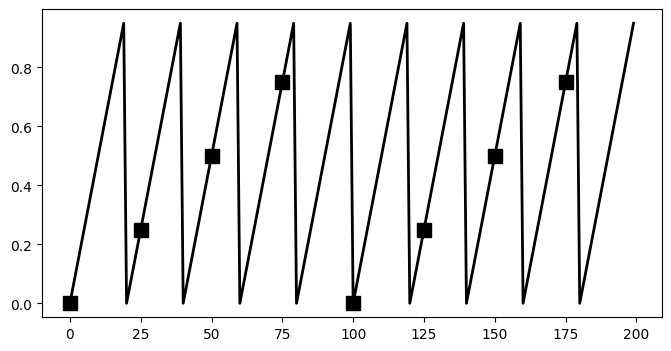

In [53]:
n_epoch = 200
beta_np_cyc = frange_cycle_linear(0.0, 1.0, n_epoch, 10, 1)

fig=plt.figure(figsize=(8,4.0))
stride = max( int(n_epoch / 8), 1)

plt.plot(range(n_epoch), beta_np_cyc, '-', label='Cyclical', marker= 's', color='k', markevery=stride,lw=2,  mec='k', mew=1 , markersize=10)
plt.show()